In [1]:
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import pandas as pd
from collections import (defaultdict,Counter)
import matplotlib.pyplot as plt
import scipy  
from scipy import stats
import seaborn as sns


In [2]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

def overlap_genelists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))



#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [3]:
#Here, we define the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

In [4]:
#Let's import the ICD-gene associations
with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [5]:
#Let's import the unified gene annotations lcc z-score
with open('output/allsources_icd_gene_dict_unified_lcczscore.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)


In [6]:
#Let's create a phenotipic epidemiological network from Elma trajectories 

In [6]:
#Let's import the trajectories

male_trajectories_df=pd.read_excel('input/All identified trajectories in males. trajectories smaller than 100 members.xlsx')
female_trajectories_df=pd.read_excel('input/All identified trajectories in females. trajectories smaller than 100 members.xlsx')

# Males

In [7]:
male_trajectories_df_copy=pd.DataFrame()
male_trajectories_df_copy['Community_ID']=male_trajectories_df['Community_ID']

new_members_of_com_list=[]
for i in male_trajectories_df['Members of community'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
male_trajectories_df_copy['Members of community']=new_members_of_com_list

male_trajectories_df_copy.head()

,Community_ID,Members of community
0,1,"K35-10-19,K37-10-19,K56-10-19,K65-10-19"
1,2,"A04-0-9,A08-0-9,B09-0-9,F50-0-9,J10-0-9"
2,3,"A09-0-9,H73-0-9,K92-0-9"
3,4,"A41-0-9,C91-0-9,N10-0-9,A41-10-19,C91-10-19"
4,5,"A49-0-9,B27-0-9,J03-0-9,J06-0-9,J11-0-9,J38-0-..."


In [8]:

male_trajectories_dict={}
for i,v in male_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members of community'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in allsources_icd_gene_dict_unified.keys():
            dis_list.append(dis)
    male_trajectories_dict[v['Community_ID']]=dis_list

#Now, let's remove all the trajectories that are obvious (same disease)
male_trajectories_dict_filtered={}
for trj,dislist in male_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in allsources_icd_gene_dict_unified.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        male_trajectories_dict_filtered[trj]=new_dislist

print(len(male_trajectories_dict_filtered))


354


In [10]:
#Some of these disease-trajectories contain the same diseases, for this reason, now we will focus only on the
#unique disease-trajectories

In [9]:
#Let's select only those communities that are unique (avoiding repetitions)

def agglomerate_dict(dict_list):
    # Reverse the dictionary: lists are keys, strings are values
    temp_dict = {}
    for k, v in dict_list.items():
        v = tuple(v)  # lists can't be hashable (used as keys), so convert it to tuple
        if v not in temp_dict:
            temp_dict[v] = [str(k)]
        else:
            temp_dict[v].append(str(k))
    
    # Agglomerate the keys that have the same list and return
    result_dict = {'_'.join(v): list(k) for k, v in temp_dict.items()}
    
    return result_dict

In [10]:
male_trajectories_dict_filtered_unique=agglomerate_dict(male_trajectories_dict_filtered)

In [11]:
len(male_trajectories_dict_filtered_unique)

317

In [14]:
len(set([x for xs in list(male_trajectories_dict_filtered_unique.values()) for x in xs]))

510

In [18]:
with open('output/male_trajectories_dict_filtered.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/male_trajectories_dict_filtered_unique.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered_unique, handle, protocol=pk.HIGHEST_PROTOCOL)

In [19]:
male_trajectories_dict_filtered_unique_agglomerated_genes={}

for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    male_trajectories_dict_filtered_unique_agglomerated_genes[agg_trj]=tot_genelsit

In [20]:
with open('output/male_trajectories_dict_filtered_unique_agglomerated_genes.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered_unique_agglomerated_genes, handle, protocol=pk.HIGHEST_PROTOCOL)

In [26]:
male_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in male_trajectories_dict_filtered_unique.items():
    overlap_list=[]
    pair_diseases_list=list(it.combinations(dislist,2))
    for p_dis in pair_diseases_list:
        try:
            overlap_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[0]],allsources_icd_gene_dict_unified[p_dis[1]]))
        except:
            overlap_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[1]],allsources_icd_gene_dict_unified[p_dis[0]]))
    if len(overlap_list)>0:
        male_trajectories_dict_filtered_unique_avg_overlap[com]=sum(overlap_list)/len(overlap_list)
  

In [27]:

dict(sorted(male_trajectories_dict_filtered_unique_avg_overlap.items(), key=lambda item: item[1],reverse=True))

{'276': 0.9960474308300395,
 '182': 0.8410545348498104,
 '36': 0.7338709677419355,
 '175': 0.7250715540779056,
 '62': 0.3817864261047825,
 '406': 0.3642054795283274,
 '146': 0.3333333333333333,
 '314': 0.3333333333333333,
 '404': 0.3333333333333333,
 '41': 0.32432432432432434,
 '432': 0.3117539026629936,
 '313': 0.30723568595504674,
 '393': 0.30723568595504674,
 '139': 0.3072356859550467,
 '368_439': 0.2871794871794872,
 '15_73': 0.28425536073382324,
 '279': 0.277162119022197,
 '99': 0.2638888888888889,
 '308': 0.2619079172008658,
 '452': 0.2619047619047619,
 '221': 0.23245058683844508,
 '174_277': 0.22751078418916304,
 '233': 0.22727272727272727,
 '363': 0.2174581327276245,
 '370': 0.2054860075029501,
 '366': 0.20402464095087314,
 '357_358': 0.18880597014925374,
 '82_87': 0.185330451721467,
 '359': 0.17777777777777778,
 '215': 0.1712663069548309,
 '40': 0.16856256463288521,
 '322': 0.16831683168316833,
 '68': 0.16666666666666666,
 '216': 0.16365806258055032,
 '184': 0.1572327044025157

In [35]:
for trj,avg_overlap in male_trajectories_dict_filtered_unique_avg_overlap.items():
    if avg_overlap>0.8 and len(male_trajectories_dict_filtered_unique[trj])<8:
        print(trj,male_trajectories_dict_filtered_unique[trj])

182 ['C82', 'C83', 'C85']
276 ['C09', 'C10']


In [31]:
for trj,avg_overlap in male_trajectories_dict_filtered_unique_avg_overlap.items():
    if avg_overlap<0.1 and len(male_trajectories_dict_filtered_unique[trj])<5:
        print(trj,avg_overlap,male_trajectories_dict_filtered_unique[trj])

3 0.0 ['A09', 'H73', 'K92']
4 0.0 ['C91', 'N10']
8 0.0 ['B27', 'J03', 'L04']
9 0.007352941176470588 ['D50', 'K50']
11 0.0 ['C71', 'H53']
12 0.0 ['D61', 'D69', 'D70']
19_53 0.06505456879948641 ['E84', 'K86']
20 0.0027359781121751026 ['E88', 'J96']
22 0.007186258457295972 ['F43', 'F81', 'F70', 'F90']
25 0.005582137161084529 ['F90', 'F91']
31_137 0.0021856818665095673 ['H50', 'H52', 'H53']
33 0.0018306735136505992 ['H61', 'H65', 'H74']
34 0.0410958904109589 ['J32', 'J35', 'J36']
35 0.02012578616352201 ['H70', 'K04', 'K12']
38 0.0 ['J31', 'J40']
39 0.012235267832021232 ['K21', 'K29', 'K44', 'K52']
42 0.009892023685127134 ['K59', 'K60', 'K61']
45 0.0 ['L90', 'N35', 'N48']
47 0.008097165991902834 ['N12', 'N39']
48 0.0 ['N10', 'N13']
50 0.0 ['B27', 'J03', 'J36']
51_181_282_362 0.0801792828685259 ['C71', 'D43']
54 0.016908212560386476 ['E87', 'F10', 'F17']
56 0.030629047171354406 ['F32', 'F33', 'F41', 'F45']
59 0.039794529981862725 ['F91', 'F90', 'F98']
60 0.012987012987012988 ['G80', 'G82']
6

In [30]:
#Let's compare against a null distribution

rd_male_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in male_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(list(allsources_icd_gene_dict_unified.keys()),len(dislist))
    for i in range(10000):
        pair_diseases_list=list(it.combinations(random_dislist,2))
        for p_dis in pair_diseases_list:
            try:
                rd_overlap_distribution.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[0]],allsources_icd_gene_dict_unified[p_dis[1]]))
            except:
                rd_overlap_distribution.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[1]],allsources_icd_gene_dict_unified[p_dis[0]]))

    rd_male_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2396407645.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


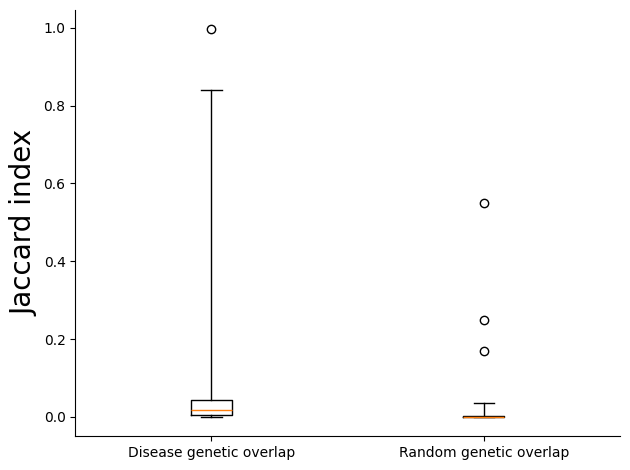

In [24]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_male_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.median(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()
plt.savefig('Figures/MaleTrajectories_JI_Random.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [34]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

1.0741432472343381e-12

In [211]:
tot_filtered_dis_list=[]
for dislist in male_trajectories_dict_filtered_unique.values():
    for dis in dislist:
        if dis not in tot_filtered_dis_list:
            tot_filtered_dis_list.append(dis)
            
print(len(tot_filtered_dis_list))

510


In [213]:
#Let's compare against a null distribution, where we sample only among the 510 diseases present in the disease trajectories

rd_male_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in male_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(tot_filtered_dis_list,len(dislist))
    for i in range(10000):
        for rd_dis1 in random_dislist:
            for rd_dis2 in random_dislist:
                if rd_dis1!=rd_dis2:
                    rd_overlap_distribution.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[rd_dis1],allsources_icd_gene_dict_unified[rd_dis2])))
                
    rd_male_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution
    
    

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_62615/671204940.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


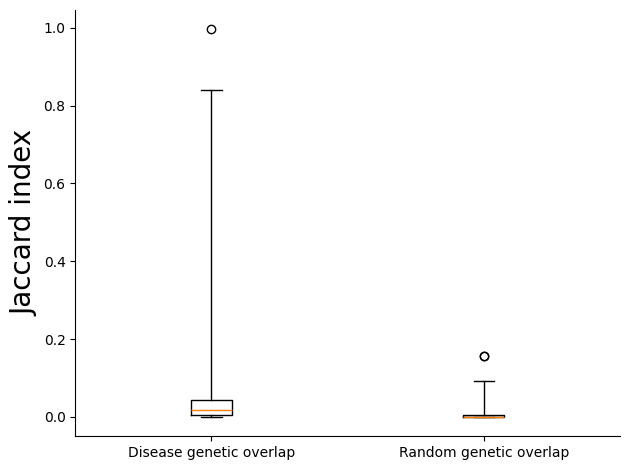

In [214]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_male_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.median(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

In [215]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

2.4371600500658573e-14

In [36]:
#Now, we will look more in the details of this shared relationships, computing the pairs/triplets and so on
#and comparing accordingly each community against its corresponding random distribution
dis_list=list(allsources_icd_gene_dict_unified.keys())
pair_diseases_list=list(it.combinations(dis_list,2))

In [37]:
jaccard_pairs_reference_list=[]

for dispair in pair_diseases_list:
    jaccard_pairs_reference_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
    
print(len(jaccard_pairs_reference_list))

522753


In [38]:
jaccard_pairs_from_n_plets_elma_list_dict={}
jaccard_pairs_from_n_plets_elma_list_pval_dict={}
jaccard_pairs_from_n_plets_elma_list_fdr_dict={}

for s in set([len(v) for v in male_trajectories_dict_filtered_unique.values()]):

    jaccard_pairs_from_n_plets_elma_list=[]
    selected_disnlets=[]
    for trj,dislist in male_trajectories_dict_filtered_unique.items():
        if len(dislist)==s:
            if dislist not in selected_disnlets:
                selected_disnlets.append(dislist)

    selected_dispair_fromnplets=[]
    for disqua in selected_disnlets:
        jo_list=[]
        dispairdisn=list(it.combinations(disqua,2))          
        for dispair in dispairdisn:
            if dispair not in selected_dispair_fromnplets:
                selected_dispair_fromnplets.append(dispair)

    for dispair in selected_dispair_fromnplets:
        try:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
        except:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
            
    jaccard_pairs_from_n_plets_elma_list_dict[s]=jaccard_pairs_from_n_plets_elma_list

    t_value,p_value=stats.ttest_ind(jaccard_pairs_reference_list,jaccard_pairs_from_n_plets_elma_list)
    jaccard_pairs_from_n_plets_elma_list_pval_dict[s] = p_value

adj_pval=fdr_adjustment(list(jaccard_pairs_from_n_plets_elma_list_pval_dict.values()),0.05)
pair_list=list(jaccard_pairs_from_n_plets_elma_list_pval_dict.keys())
for i in range(len(adj_pval)):
    jaccard_pairs_from_n_plets_elma_list_fdr_dict[pair_list[i]]=adj_pval[i]


In [40]:
with open('output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_male.pickle', 'wb') as handle:
    pk.dump(jaccard_pairs_from_n_plets_elma_list_fdr_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [39]:
jaccard_pairs_from_n_plets_elma_list_fdr_dict

{2: 5.556190958540094e-07,
 3: 8.894441509298105e-50,
 4: 2.0632846305100448e-34,
 5: 6.180516508886445e-05,
 6: 1.1412932537678989e-07,
 7: 0.0005208651502662575,
 8: 0.2998198806779671,
 9: 0.744247391359813,
 10: 0.7760793933796498,
 11: 0.7100127695022482,
 12: 0.7873634995944585,
 13: 0.016973209211140684,
 14: 0.7873634995944585,
 16: 0.7873634995944585,
 20: 0.9006529237811766,
 21: 0.7873634995944585,
 26: 0.9035644307843262,
 32: 0.8054572995106777,
 68: 4.1178223195415095e-12}

In [34]:
#Here, we calculate the average shortest path of the DDN, and we compare the distribution of average shortest path
#between disease pairs within the same trajectory versus the average shortest path of the DDN

#Let's import the ICD Genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')

#Let's extract the lcc
G_gene_icd_disp_significant_post_lcc = G_gene_icd_disp_significant_post.subgraph(max(nx.connected_components(G_gene_icd_disp_significant_post), key=len))

#Avg shortest path
G_gene_icd_disp_significant_post_avg_sp = nx.average_shortest_path_length(G_gene_icd_disp_significant_post_lcc)

In [36]:
male_trajectories_dict_filtered_unique_DDN_avgsp = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    sp_list = []
    n_dislist = set(dislist) & G_gene_icd_disp_significant_post_lcc.nodes()
    pair_diseases_list=list(it.combinations(n_dislist,2))
    for dispair in pair_diseases_list:
        sp_list.append(nx.shortest_path_length(G_gene_icd_disp_significant_post_lcc, source=dispair[0], target=dispair[1]))
    male_trajectories_dict_filtered_unique_DDN_avgsp[trj] = np.mean(sp_list)
    

/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


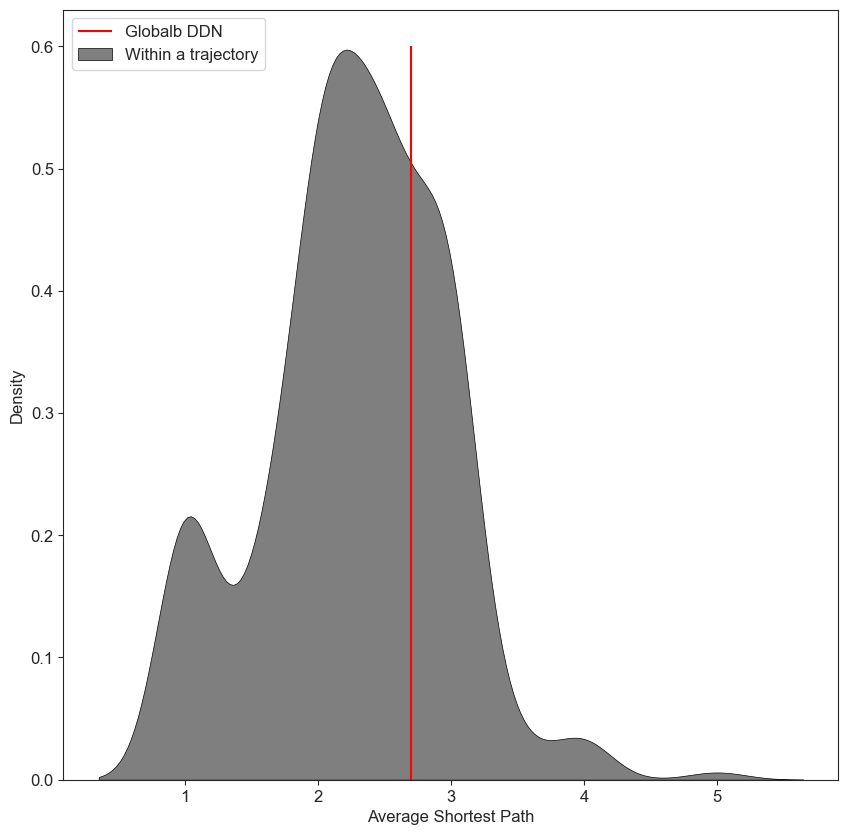

In [43]:
#Let's plot the distribution of all lcc z-scores

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(G_gene_icd_disp_significant_post_avg_sp,ymin=0,ymax=0.6,color='r',label='Globalb DDN')
sns.kdeplot(list(male_trajectories_dict_filtered_unique_DDN_avgsp.values()),color='k',lw=.5,alpha=.5,fill=True,label='Within a trajectory')

plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('Average Shortest Path',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/DDN_ShortestPath.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [47]:

male_trajectories_dict_filtered_unique_DDN_avgsp_sort = {k: v for k, v in sorted(male_trajectories_dict_filtered_unique_DDN_avgsp.items(), key=lambda item: item[1],reverse=False)}




In [ ]:
#Let's calculate the genetic (largest connected component) z-score of the genese perturbed by each trajectory

In [61]:
#Let's import the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z


In [64]:
male_trajectories_dict_filtered_unique_distinct_zscore_dict={}
male_trajectories_dict_filtered_unique_agglomerated_zscore_dict={}

for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
    z_score_list=[]
    for dis in dislist:
        z_score_list.append(allsources_icd_gene_dict_unified_lcczscore[dis])
    male_trajectories_dict_filtered_unique_distinct_zscore_dict[agg_trj]=z_score_list
    
for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    male_trajectories_dict_filtered_unique_agglomerated_zscore_dict[agg_trj]=net_modularity(tot_genelsit,G_ppi)
    

In [65]:
with open('output/male_trajectories_dict_filtered_unique_agglomerated_zscore_dict.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered_unique_agglomerated_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2328643788.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,


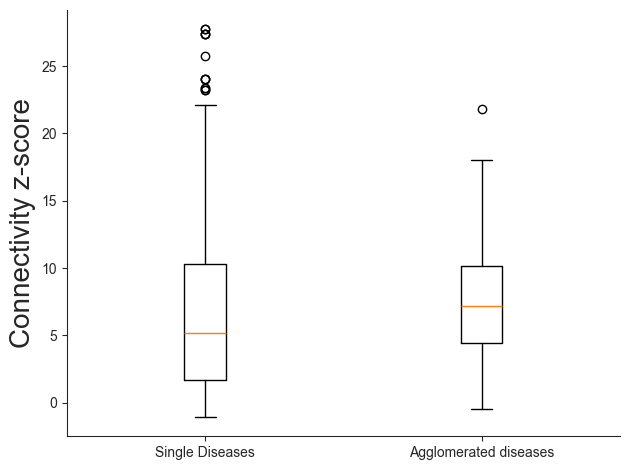

In [66]:
#Let's plot these boxplots

z_score_single_diseases=[]
z_score_agglomerated_diseases=[round(float(z),3) for z in male_trajectories_dict_filtered_unique_agglomerated_zscore_dict.values() if z!='nan']

for trj,z_scorelist in male_trajectories_dict_filtered_unique_distinct_zscore_dict.items():
    for z in z_scorelist:
        if z!='nan':
            z_score_single_diseases.append(round(float(z),3))
            

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Single Diseases','Agglomerated diseases']
plt.ylabel('Connectivity z-score',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[z_score_single_diseases,z_score_agglomerated_diseases]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

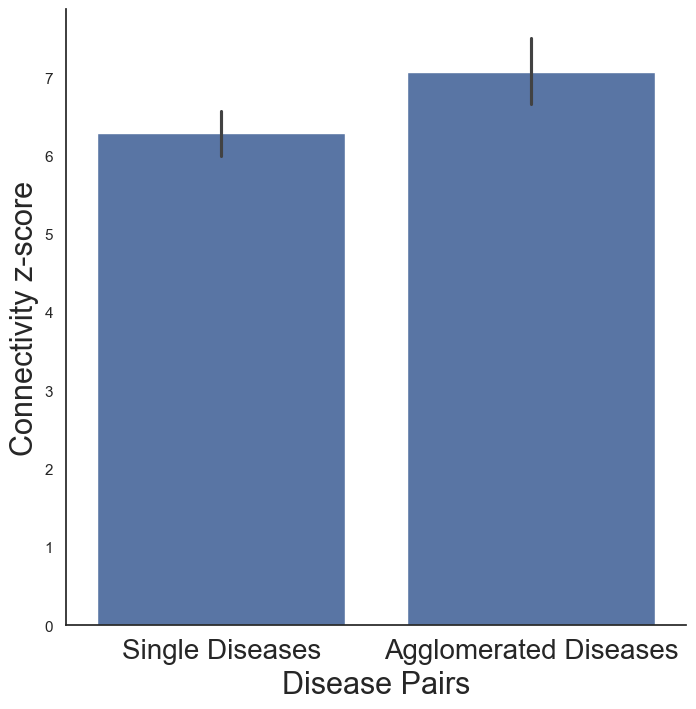

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

connectivity_df=pd.DataFrame()

status_list=[]
conn_list=[]

for i in z_score_single_diseases:
    status_list.append("Single Diseases")
    conn_list.append(i)
    
for i in z_score_agglomerated_diseases:
    status_list.append("Agglomerated Diseases")
    conn_list.append(i)

connectivity_df['Status']=status_list
connectivity_df['Connectivity']=conn_list

# Create a boxplot using seaborn
fig, ax = plt.subplots(figsize=(8, 8))
sns.set(style="white")

g=sns.barplot(x='Status', y='Connectivity', data=connectivity_df)
#g.set_yscale("log")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.xticks(fontsize=20)

plt.xlabel('Disease Pairs', fontsize=22)
plt.ylabel('Connectivity z-score', fontsize=22)
plt.savefig('Figures/Agglomerate_PPI_zscore.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [68]:

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(z_score_single_diseases,z_score_agglomerated_diseases)
p_value

0.017714925175436665

In [60]:
#Let's check for the disease proximity in the PPI

In [61]:
with open('output/icd10_male_trajectories_dict_filtered_unique_proximity_proximity.pickle', 'rb') as handle:
    icd10_male_trajectories_dict_filtered_unique_proximity = pk.load(handle)

In [377]:
def random_selection(G,size):
    while True:
        rnd_sample=rd.sample(list(G.nodes()),size)
        if 'nan' in rnd_sample:
            rnd_sample=rd.sample(list(G.nodes()),size)
        else:
            break
    return rnd_sample


def calculate_closest_distance(G_ppi_lcc, nodes_from, nodes_to):
    values_outer = []
    for node_from in nodes_from:
        values = []
        for node_to in nodes_to:
            if node_from==node_to:
                val =0
            else:
                val=len(nx.shortest_path(G_ppi_lcc,source=node_from, target=node_to))
            values.append(val)
        d = min(values)
        #print d,
        values_outer.append(d)
    d = np.mean(values_outer)
    #print d
    return d

def calculate_proximity(network, nodes_from, nodes_to, exp_random):   #let's calculate the proximity between the two sets
    d=calculate_closest_distance(network,nodes_from,nodes_to)         #exposure and disease genesets
    m=exp_random[len(nodes_from),len(nodes_to)][0]
    s=exp_random[len(nodes_from),len(nodes_to)][1]
    if s == 0:
        z = 0.0
    else:
        z = (d - m) / s
    return d, z, (m, s) #(z, pval)


In [379]:
#Let's complete the proximity calculation

for dispair in missing_dispairs:
    geneset1=icd_genes_ppi_dict[dispair[0]]
    geneset2=icd_genes_ppi_dict[dispair[1]]
    dis_random_distance={}
    S = 1000
    l_rnd_dist = []
    for s in range(S):
        rnd_dis1_set=random_selection(G_ppi,len(geneset1))
        rnd_dis2_set=random_selection(G_ppi,len(geneset2))
        rnd_dist=calculate_closest_distance(G_ppi,rnd_dis1_set,rnd_dis2_set)
        l_rnd_dist.append(rnd_dist)
    mu = np.mean(l_rnd_dist)
    std = np.std(l_rnd_dist)

    dis_random_distance[len(geneset1),len(geneset2)]=[mu,std]
    icd10_male_trajectories_dict_filtered_unique_proximity[dispair[0],dispair[1]]=calculate_proximity(G_ppi,geneset1,geneset2,dis_random_distance)
    


In [62]:


within_pairwise_dist=[]
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    pairwise_dis=it.combinations(dislist,2)
    for dis_pair in pairwise_dis:
        if dis_pair not in within_pairwise_dist:
            within_pairwise_dist.append(dis_pair)
    
    

In [63]:

within_trj_z_score_list=[]
within_trj_net_distance_list=[]
other_trj_z_score_list=[]
other_trj_net_distance_list=[]


for dispair_prox, prox in icd10_male_trajectories_dict_filtered_unique_proximity.items():
    if dispair_prox in within_pairwise_dist:
        within_trj_z_score_list.append(prox[1])
        within_trj_net_distance_list.append(prox[0])
    else:
        other_trj_z_score_list.append(prox[1])
        other_trj_net_distance_list.append(prox[0])

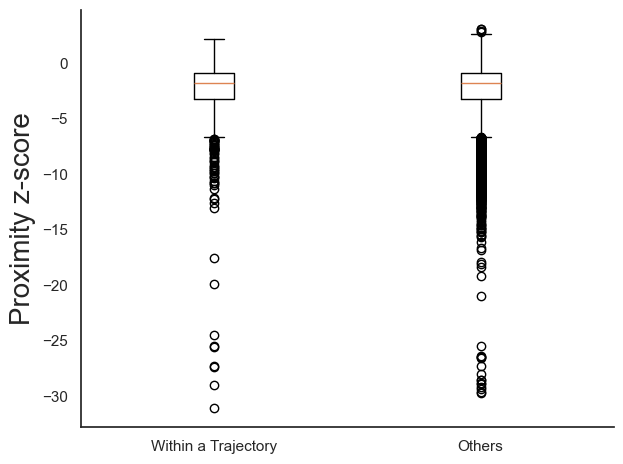

In [64]:
#Let's plot these boxplots


import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Within a Trajectory','Others']
plt.ylabel('Proximity z-score',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[within_trj_z_score_list,other_trj_z_score_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

In [65]:
from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(within_trj_z_score_list,other_trj_z_score_list)
p_value

0.04903006175488214

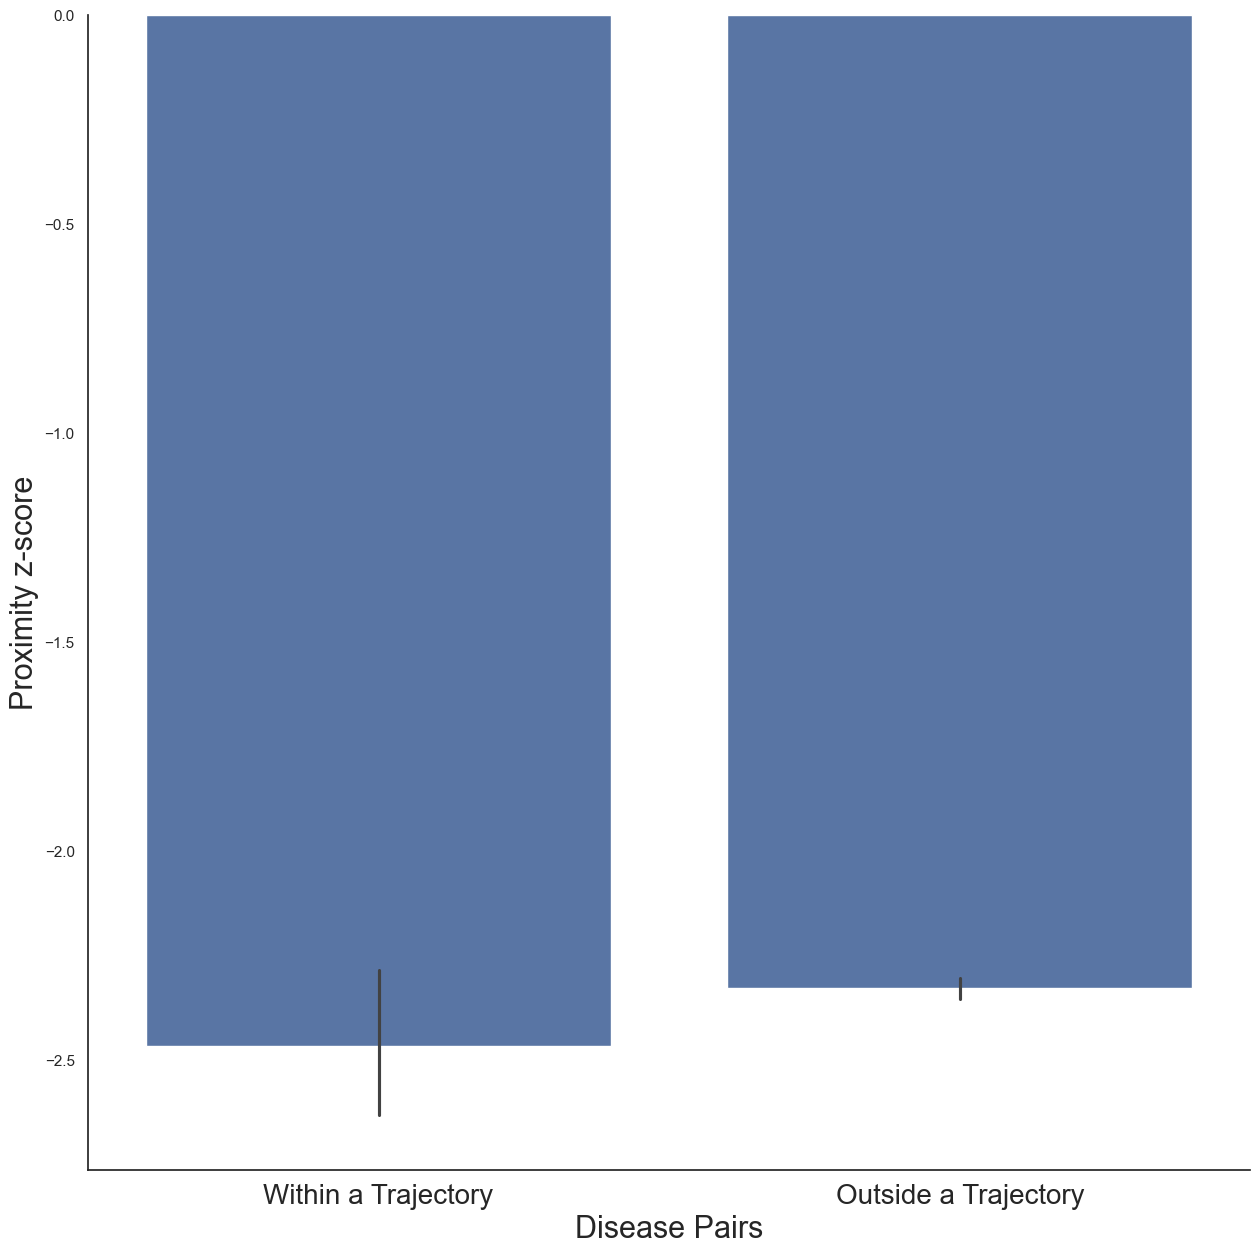

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

proximity_df=pd.DataFrame()

status_list=[]
prox_list=[]

for i in within_trj_z_score_list:
    status_list.append("Within a Trajectory")
    prox_list.append(i)
    
for i in other_trj_z_score_list:
    status_list.append("Outside a Trajectory")
    prox_list.append(i)

proximity_df['Status']=status_list
proximity_df['Proximity']=prox_list

# Create a boxplot using seaborn
fig, ax = plt.subplots(figsize=(15, 15))
sns.set(style="white")

g=sns.barplot(x='Status', y='Proximity', data=proximity_df)
#g.set_yscale("log")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.xticks(fontsize=20)

plt.xlabel('Disease Pairs', fontsize=22)
plt.ylabel('Proximity z-score', fontsize=22)

plt.show()

Text(0, 0.5, 'Number of disease-pairs')

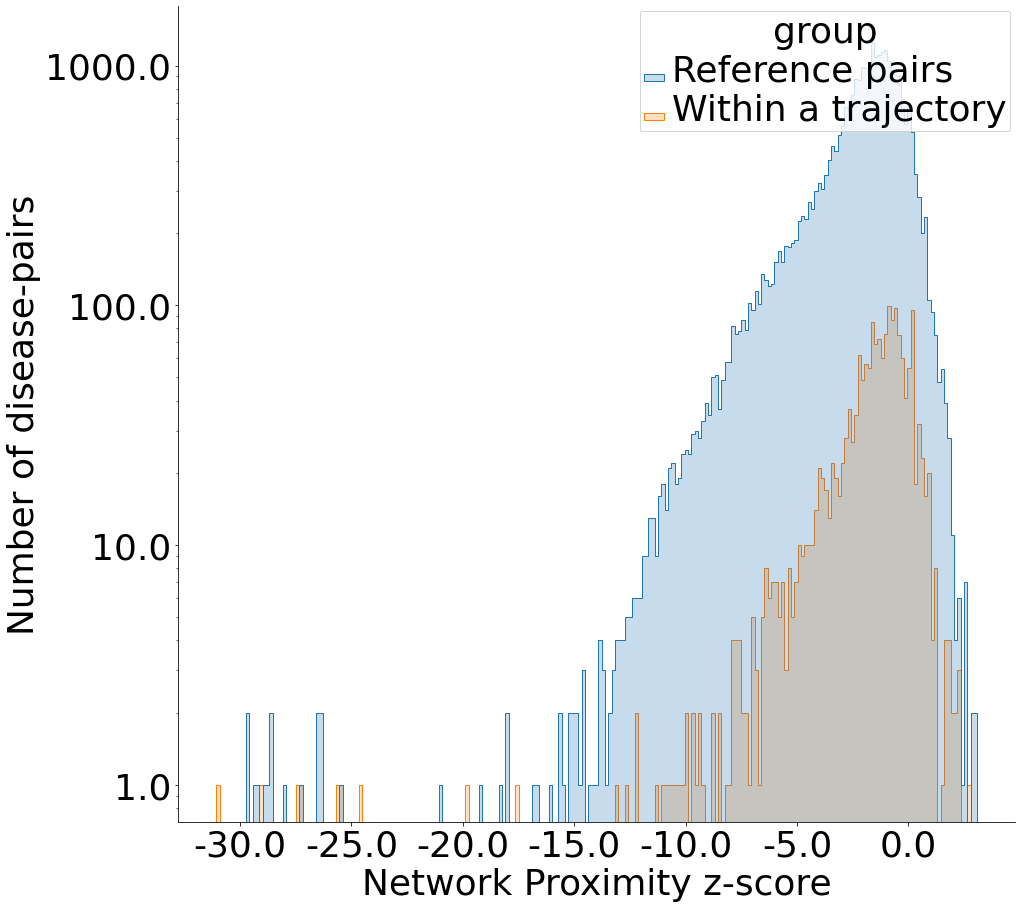

In [383]:
import seaborn as sns

genedispairs_df=pd.DataFrame()

net_proximity_list=[]
group=[]
for ov in other_trj_z_score_list:
    net_proximity_list.append(float(ov))
    group.append("Reference pairs")
        
for ov in within_trj_z_score_list:
    net_proximity_list.append(float(ov))
    group.append("Within a trajectory")
    


genedispairs_df['ov']=net_proximity_list
genedispairs_df['group']=group
fig, ax = plt.subplots(figsize=(15,15))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.yscale('log')
sns.histplot(
    genedispairs_df, x="ov", hue="group", element="step",palette='tab10',
)
ax.set_xticklabels([round(float(i),2) for i in list(ax.get_xticks())], size = 36)
ax.set_yticklabels(ax.get_yticks(), size = 36)
plt.setp(ax.get_legend().get_texts(), fontsize='36') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='36') # for legend title
plt.xlabel('Network Proximity z-score',fontsize=36)
plt.ylabel('Number of disease-pairs', fontsize=36)

/Users/lsd/opt/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1376: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


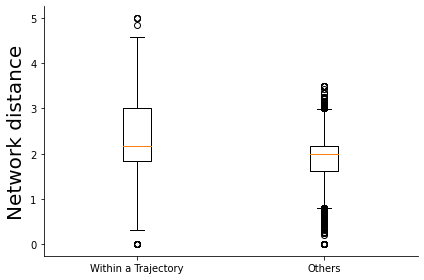

In [384]:
#Let's plot these boxplots


import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Within a Trajectory','Others']
plt.ylabel('Network distance',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[within_trj_net_distance_list,other_trj_net_distance_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

Text(0, 0.5, 'Number of disease-pairs')

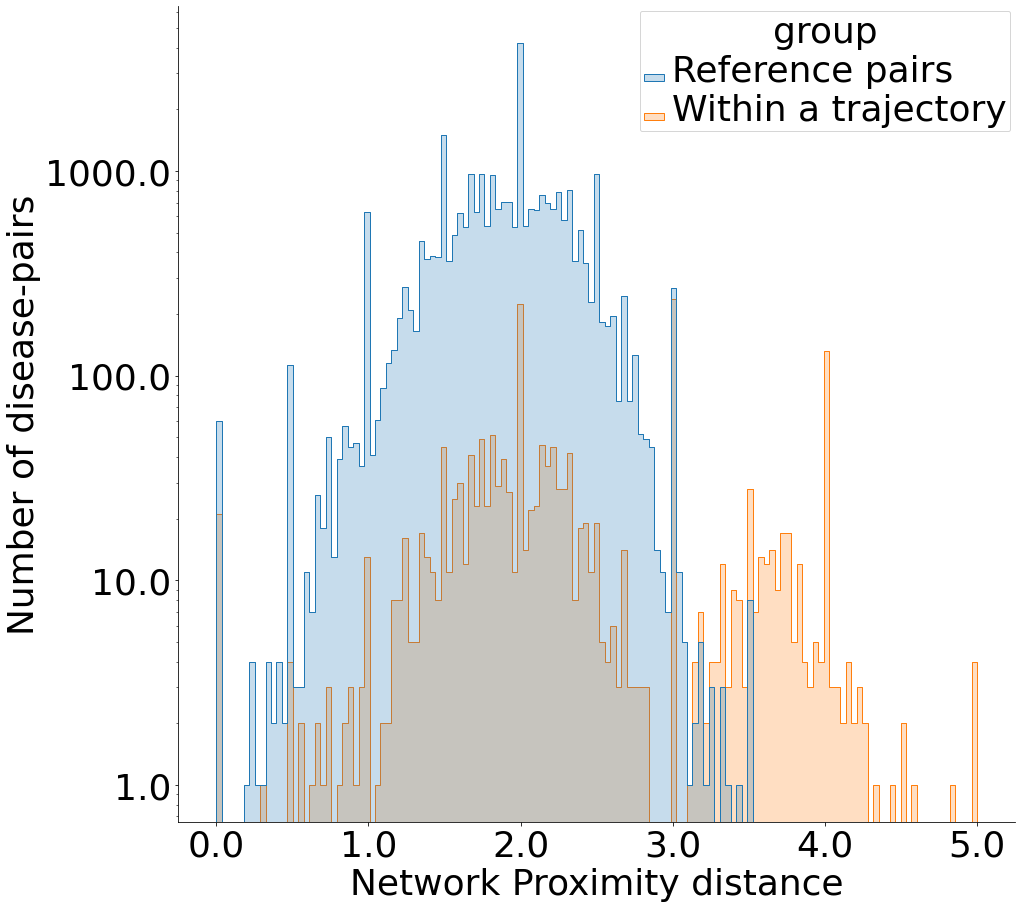

In [385]:
import seaborn as sns

genedispairs_df=pd.DataFrame()

net_proximity_list=[]
group=[]
for ov in other_trj_net_distance_list:
    net_proximity_list.append(float(ov))
    group.append("Reference pairs")
        
for ov in within_trj_net_distance_list:
    net_proximity_list.append(float(ov))
    group.append("Within a trajectory")
    


genedispairs_df['ov']=net_proximity_list
genedispairs_df['group']=group
fig, ax = plt.subplots(figsize=(15,15))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.yscale('log')
sns.histplot(
    genedispairs_df, x="ov", hue="group", element="step",palette='tab10',
)
ax.set_xticklabels([round(float(i),2) for i in list(ax.get_xticks())], size = 36)
ax.set_yticklabels(ax.get_yticks(), size = 36)
plt.setp(ax.get_legend().get_texts(), fontsize='36') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='36') # for legend title
plt.xlabel('Network Proximity distance',fontsize=36)
plt.ylabel('Number of disease-pairs', fontsize=36)

In [388]:
len([i for i in within_trj_z_score_list if i<-2])/len(within_trj_z_score_list)

0.3187118267629095

In [389]:
male_trajectories_dict_filtered_unique_prox_zscore_dict={}
missing_dispairs=[]
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    prox_list=[]
    pairwise_dis=list(it.combinations(dislist,2))
    for dis_pair in pairwise_dis:
        try:
            try:
                prox_list.append(icd10_male_trajectories_dict_filtered_unique_proximity[dis_pair[0],dis_pair[1]][1])
            except:
                prox_list.append(icd10_male_trajectories_dict_filtered_unique_proximity[dis_pair[1],dis_pair[0]][1])
        except:
            missing_dispairs.append(dis_pair)
            
    male_trajectories_dict_filtered_unique_prox_zscore_dict[trj]=np.mean(prox_list)


In [391]:
male_trajectories_dict_filtered_unique_prox_zscore_dict

{'1_2_3_4_5_6_99': -1.5653756495090791,
 '9_10_11_12_100_101_154': -2.1351162404971737,
 '13_227': -0.4401481063104593,
 '15_16_73': -3.9819914461804626,
 '18': -0.48145597805835744,
 '22': -0.1447396044590852,
 '23': -4.279920035293529,
 '24_25': -0.5422314964894683,
 '27_28_29': -0.39626925050185463,
 '39_40': 0.002380103440056631,
 '41_42_234': -0.8122143098601243,
 '50': -1.8527173781753579,
 '51_181_282_362_402_403_404': -6.7918171150686035,
 '56': -0.42557150686060435,
 '57': -0.8847709408468601,
 '59': -2.0922775700635072,
 '61': -5.442960981276046,
 '62': -1.04122596404851,
 '63_326_327_455': 0.4406753814309485,
 '64_65': 0.6846856832182645,
 '66': -1.63003530500098,
 '68': -1.1510182795843134,
 '70_114': -2.906424028565798,
 '72': -6.402798066675368,
 '74': -1.6717752492037858,
 '77': -2.5469966483510618,
 '78': -7.444912975513138,
 '79_80_81': -0.9020555050659272,
 '82_87_88': -3.713447879462143,
 '84': -0.4682591699696143,
 '91_191_395_396_397': -1.0110814027100166,
 '92': -

In [12]:
#Let's create a network now out of this condensed unique trajectories
#We are going to focus on those trajectories that have less than 8 elements because we have shown that those are the ones
#that have the highest coherence with the genetic basis
G_elma_icd_male = nx.Graph() 

for dislist in list(male_trajectories_dict_filtered_unique.values()):
    if len(dislist)<8:
        for dis1 in dislist:
            for dis2 in dislist:
                if dis1!=dis2:
                    G_elma_icd_male.add_edge(dis1, dis2)
                
print(G_elma_icd_male.number_of_nodes())
print(G_elma_icd_male.number_of_edges())

385
1281


In [13]:
G_elma_icd_male_df = nx.to_pandas_edgelist(G_elma_icd_male,'Dis A', 'Dis B')
G_elma_icd_male_df.to_csv('output/G_elma_icd_male_df.tsv', sep = '\t')


In [123]:
from cartoGRAPHs import *
import random 
from sklearn.decomposition import PCA
from sklearn import preprocessing
import json
import matplotlib.colors as mcolors
import colorsys
import pickle as pk

In [124]:
icd_cat = set([str(n[0]) for n in G_elma_icd_male.nodes()])

In [125]:
icd_code_comm = {}
for icd in icd_cat:
    nodelist = []
    for node in G_elma_icd_male.nodes():
        if icd in node:
            nodelist.append(node)
    icd_code_comm[icd] = nodelist

In [126]:
# creating a feature dataframe based on community
feature_df = pd.DataFrame()
    
for g in G_elma_icd_male.nodes():
    feature_list=[]
    for icd, nodelist in icd_code_comm.items():
        if g in nodelist:
            feature_list.append(1)
        else:
            feature_list.append(0)
    feature_df[g]=feature_list


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2304266199.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2304266199.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2304266199.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [127]:
feature_df_T=feature_df.T

In [128]:
r = 0.9
alpha = 1.0

A = nx.adjacency_matrix(G_elma_icd, nodelist=list(G_elma_icd_male.nodes()))
DM_m = rnd_walk_matrix2(A, r, alpha, len(G_elma_icd_male.nodes()))
FM_structural = pd.DataFrame(DM_m)
FM_structural.sum(axis=1) # axis=1 for columns i.e. features = sum 1
FM_structural.index=list(G_elma_icd_male.nodes())
FM_structural.columns=list(G_elma_icd_male.nodes())
FM_structural

,K35,K37,K56,K65,A04,A08,B09,F50,J10,A09,...,N50,I65,C80,D63,D31,H04,D36,D75,G56,M72
K35,9.019078e-01,3.094006e-02,1.055160e-02,1.574247e-02,1.596409e-06,1.537065e-04,4.086918e-06,4.086918e-06,4.086918e-06,1.693346e-09,...,3.923793e-11,1.283668e-09,7.636399e-08,7.636399e-08,7.029078e-12,7.029078e-12,3.135799e-06,1.174370e-09,3.800472e-12,3.800472e-12
K37,3.094006e-02,9.019078e-01,1.055160e-02,1.574247e-02,1.596409e-06,1.537065e-04,4.086918e-06,4.086918e-06,4.086918e-06,1.693346e-09,...,3.923793e-11,1.283668e-09,7.636399e-08,7.636399e-08,7.029078e-12,7.029078e-12,3.135799e-06,1.174370e-09,3.800472e-12,3.800472e-12
K56,3.165481e-02,3.165481e-02,9.017368e-01,1.625256e-02,8.474271e-05,1.313491e-02,3.478856e-04,3.478856e-04,3.478856e-04,8.675501e-08,...,2.617260e-09,8.548731e-08,2.553206e-07,2.553206e-07,5.576177e-10,5.576177e-10,2.677484e-04,9.751842e-08,3.124464e-10,3.124464e-10
K65,3.148495e-02,3.148495e-02,1.083504e-02,9.022285e-01,3.609656e-05,1.583692e-04,5.117520e-06,5.117520e-06,5.117520e-06,4.037741e-08,...,5.309596e-10,1.746119e-08,4.258898e-06,4.258898e-06,3.594139e-11,3.594139e-11,3.377395e-06,3.101160e-09,1.212979e-11,1.212979e-11
A04,9.046315e-06,9.046315e-06,1.600696e-04,1.022736e-04,9.013798e-01,1.393479e-02,2.408723e-02,2.408723e-02,2.408723e-02,3.910857e-10,...,1.280740e-05,4.214459e-04,3.811798e-06,3.811798e-06,7.749182e-10,7.749182e-10,2.147089e-04,2.975483e-06,3.262102e-10,3.262102e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H04,9.372103e-12,9.372103e-12,2.478301e-10,2.396093e-11,1.823337e-10,1.022646e-11,5.067373e-12,5.067373e-12,5.067373e-12,3.390296e-15,...,2.521961e-13,8.182336e-12,1.315837e-09,1.315837e-09,2.328061e-02,9.013294e-01,4.720366e-08,1.680762e-13,2.757962e-13,2.757962e-13
D36,4.181065e-06,4.181065e-06,1.189993e-04,2.251596e-06,5.051974e-05,2.514555e-06,1.395639e-06,1.395639e-06,1.395639e-06,5.442209e-10,...,1.219756e-07,3.959107e-06,1.077619e-05,1.077619e-05,4.720366e-08,4.720366e-08,9.010214e-01,1.322797e-09,3.649638e-12,3.649638e-12
D75,1.565826e-09,1.565826e-09,4.334152e-08,2.067440e-09,7.001135e-07,1.146266e-08,1.872569e-08,1.872569e-08,1.872569e-08,1.299794e-09,...,1.026785e-11,3.275588e-10,5.072190e-10,5.072190e-10,1.680762e-13,1.680762e-13,1.322797e-09,9.014208e-01,1.016054e-11,1.016054e-11
G56,2.533648e-12,2.533648e-12,6.943253e-11,4.043263e-12,3.837767e-11,1.617243e-12,1.052498e-12,1.052498e-12,1.052498e-12,2.087710e-12,...,6.574367e-16,2.049836e-14,8.280326e-13,8.280326e-13,1.378981e-13,1.378981e-13,1.824819e-12,5.080268e-12,9.026399e-01,4.549703e-02


In [137]:
scalar_val = 0.55
layout_method = 'modulated-scal'+str(scalar_val)
DF_structural = FM_structural
DF_functional = feature_df
DF_merge = feature_modulation(DF_structural,DF_functional, scalar_val)

n_n = 10
spr = 2
md = 1.5
metr2D = 'cosine'

posG2D_modulated = layout_portrait_umap(G_elma_icd_male,
                                   DF_merge,
                                   2,
                                   n_neighbors=n_n, 
                                   spread=spr, 
                                   min_dist=md, 
                                   metric=metr2D
                                  )

posG2D_new = posG2D_modulated

/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [138]:
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1

edge_opacity = 0.5
edge_width = 0.1
edge_color = '#A1A1A1' #'#6C6C6C' #'#d3d3d3'

In [139]:
with open('output/icd_cat_color_mapping.pickle', 'rb') as handle:
    icd_cat_color_mapping = pk.load(handle)

In [140]:
def draw_node_degree(G, scalef):
    '''
    Calculate the node degree from graph positions (dict).
    Return list of radii for each node (2D). 
    '''
    
    l_size = {}
    for node in G.nodes():
        k = nx.degree(G, node)
        if k > 0:
            R = k*scalef +0.25 #math.log(k) * scalef + 0.25
        else: 
            R = 0.1
        l_size[node] = R
        
    return l_size

scale_factor = 15 #0.15
d_size = draw_node_degree(G_elma_icd_male, scale_factor)
l_size = [d_size[n] for n in posG2D_new.keys()]

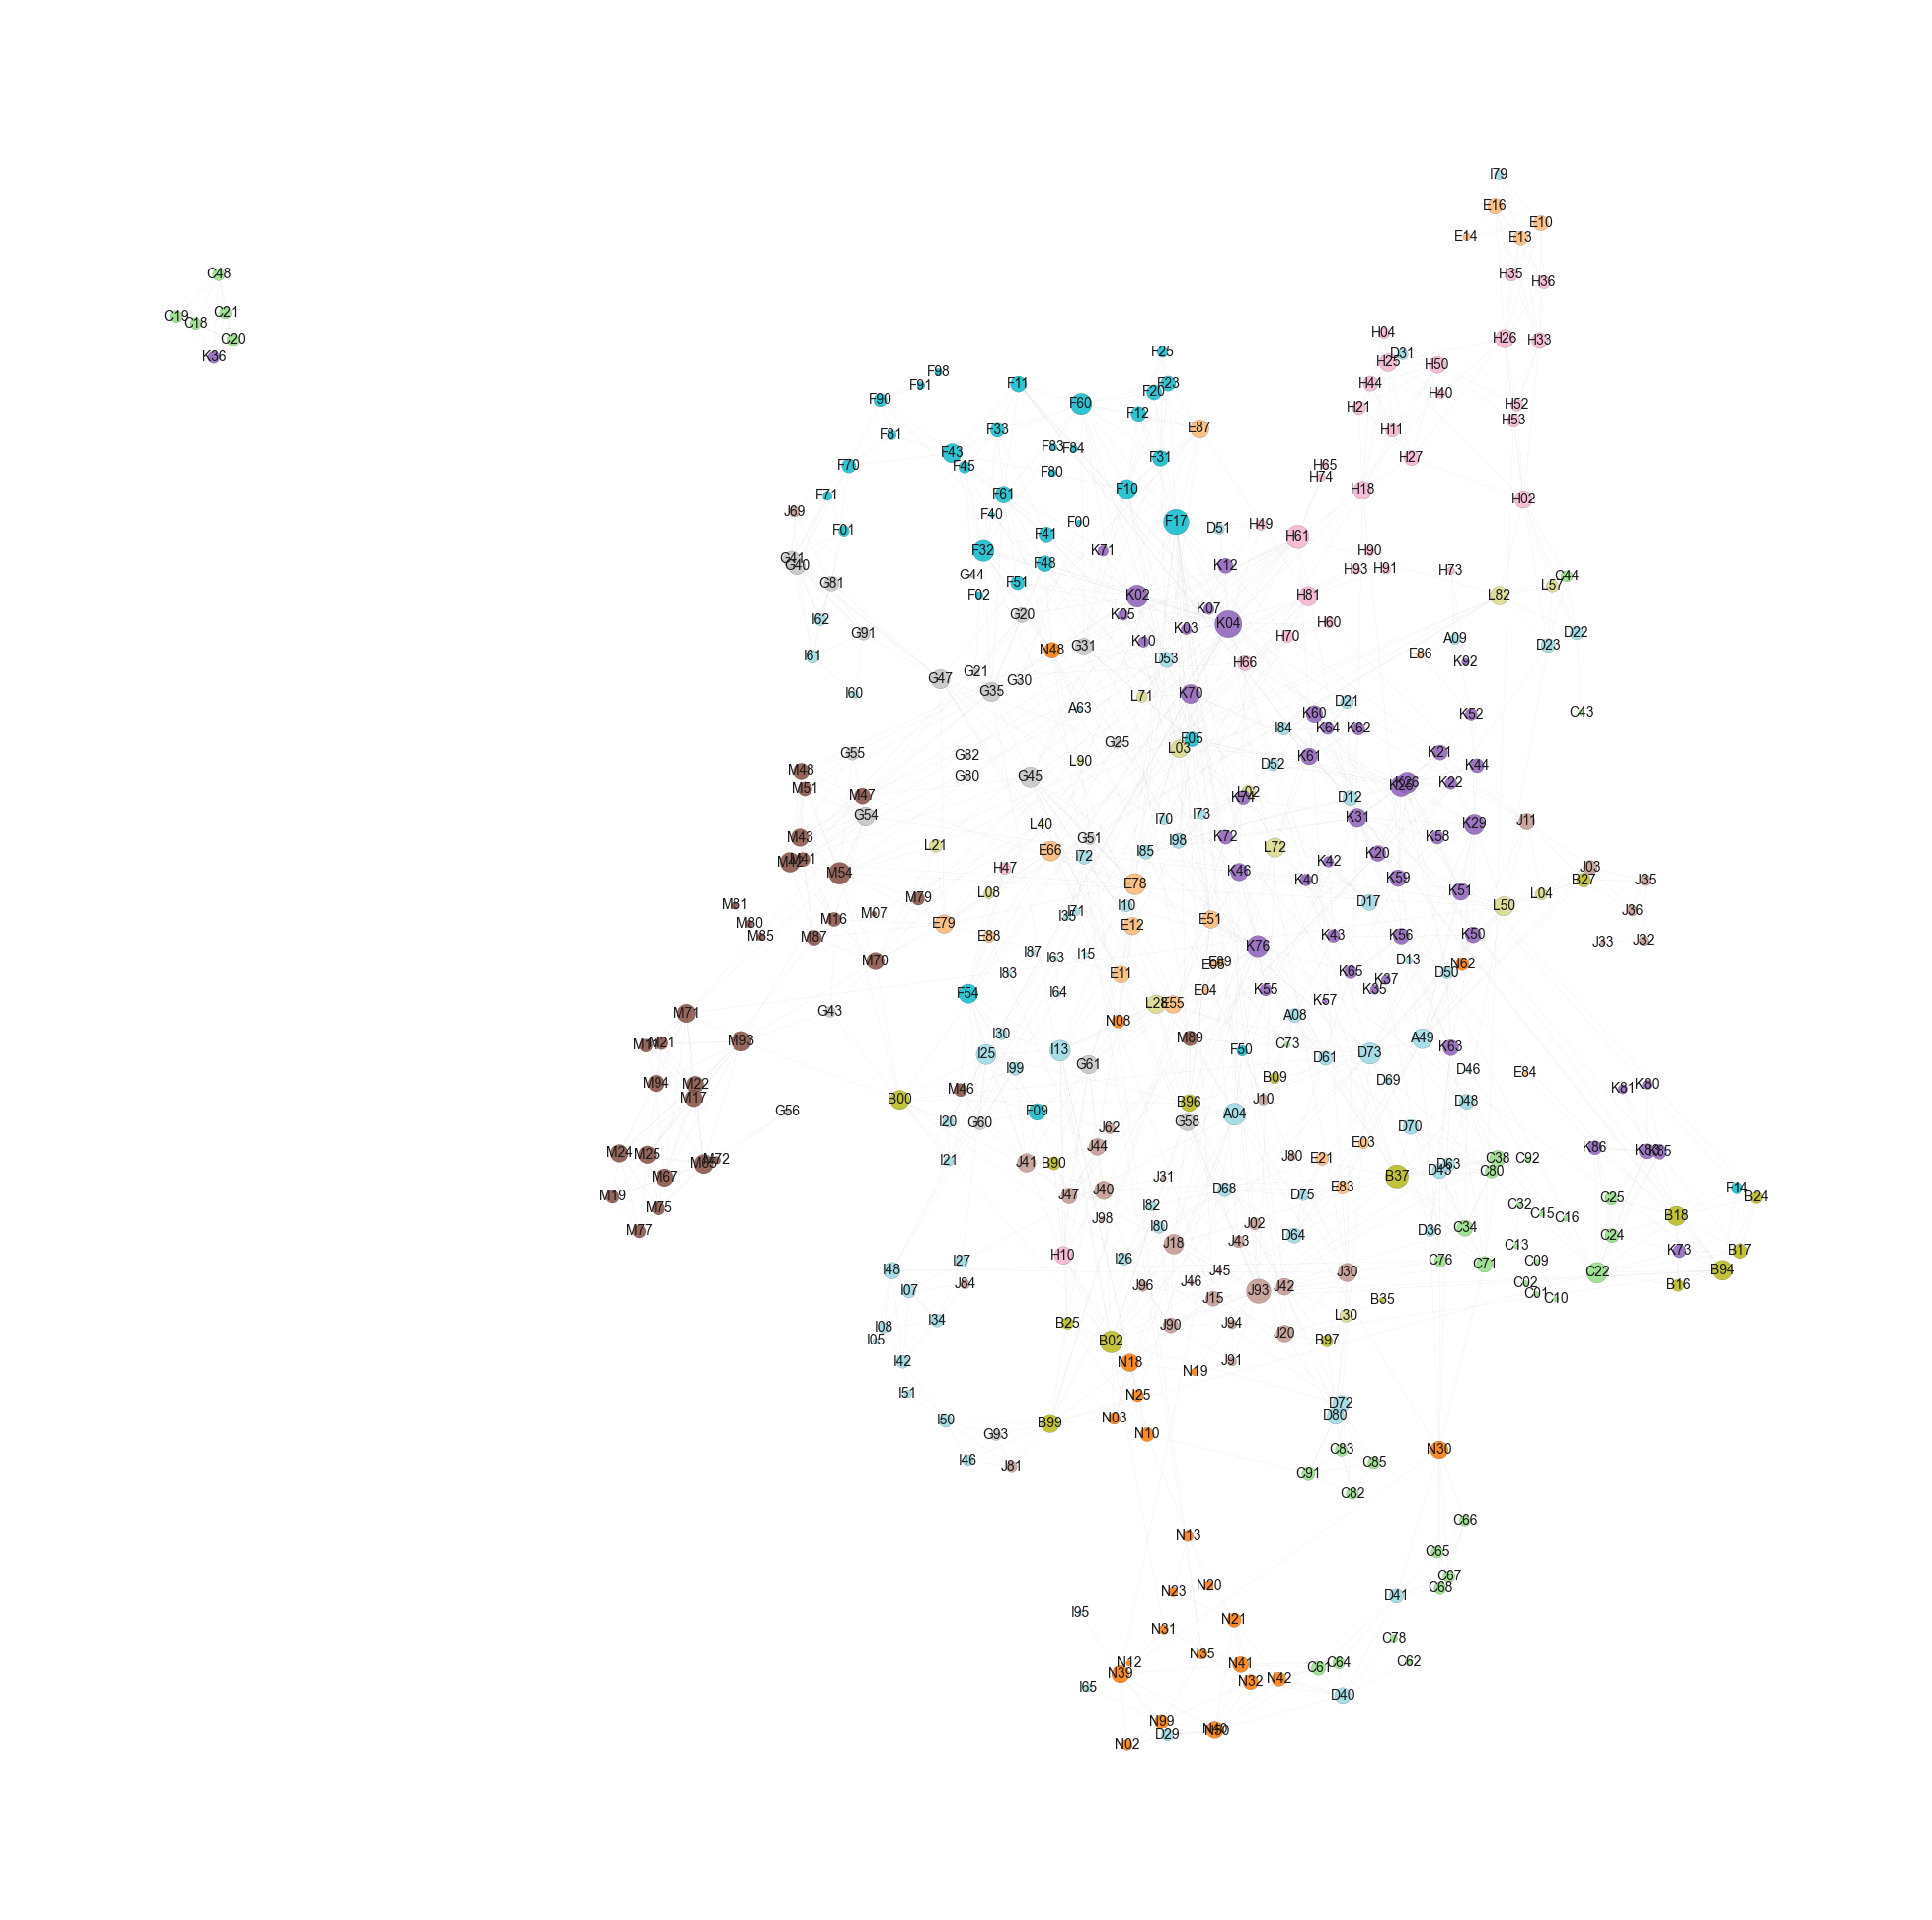

In [141]:
color_list = []
for node in posG2D_new.keys():
    color_list.append(icd_cat_color_mapping[node[0]])


plt.figure(figsize=(25,25))
nx.draw_networkx_nodes(G_elma_icd_male, 
                       posG2D_new,
                       edgecolors = node_edge_col, 
                       linewidths = node_linewidth, 
                       node_color = color_list, 
                       node_size = l_size, 
                       alpha = opacity_nodes)

nx.draw_networkx_edges(G_elma_icd_male, posG2D_new,  width = edge_width, edge_color = edge_color, alpha = edge_opacity)
plt.box(False)
nx.draw_networkx_labels(G_elma_icd_male,pos=posG2D_new,font_size=10)
plt.savefig('Figures/Fig3H.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()



In [232]:
G_elma_icd_male_degree=dict(nx.degree(G_elma_icd_male))
dict(sorted(G_elma_icd_male_degree.items(), key=lambda item: item[1],reverse=True))

{'K04': 26,
 'F17': 23,
 'J93': 21,
 'B37': 19,
 'H61': 18,
 'A04': 17,
 'M54': 17,
 'B02': 17,
 'E78': 16,
 'K76': 16,
 'K02': 16,
 'F32': 16,
 'F60': 16,
 'D73': 16,
 'K25': 15,
 'K26': 15,
 'C22': 15,
 'I13': 15,
 'A49': 14,
 'E66': 14,
 'K29': 14,
 'B94': 14,
 'J18': 14,
 'M93': 14,
 'M42': 14,
 'G45': 14,
 'I25': 14,
 'L50': 13,
 'F43': 13,
 'G47': 13,
 'M65': 13,
 'F10': 13,
 'K70': 13,
 'B18': 13,
 'L72': 13,
 'G35': 13,
 'F54': 13,
 'B00': 13,
 'J30': 12,
 'J40': 12,
 'E87': 12,
 'E79': 12,
 'K31': 12,
 'H81': 12,
 'G54': 12,
 'H26': 12,
 'M71': 12,
 'B99': 12,
 'J41': 12,
 'G61': 12,
 'L28': 12,
 'L03': 11,
 'M24': 11,
 'M25': 11,
 'M67': 11,
 'N39': 11,
 'N18': 11,
 'K51': 11,
 'M43': 11,
 'N40': 11,
 'E12': 11,
 'K46': 11,
 'G58': 11,
 'H25': 11,
 'H10': 11,
 'E55': 11,
 'M70': 11,
 'N30': 11,
 'H02': 11,
 'E51': 11,
 'L82': 11,
 'H18': 11,
 'J20': 10,
 'J42': 10,
 'D80': 10,
 'G40': 10,
 'G41': 10,
 'M22': 10,
 'H50': 10,
 'K59': 10,
 'K60': 10,
 'K61': 10,
 'E11': 10,
 'M1

In [143]:
for e in G_elma_icd_male.edges():
    if 'K04' in e:
        print(e)

('J11', 'K04')
('J30', 'K04')
('F17', 'K04')
('K02', 'K04')
('H60', 'K04')
('H66', 'K04')
('H70', 'K04')
('K04', 'K12')
('K04', 'K03')
('K04', 'K07')
('K04', 'F32')
('K04', 'F48')
('K04', 'B37')
('K04', 'F51')
('K04', 'F54')
('K04', 'I25')
('K04', 'I13')
('K04', 'I30')
('K04', 'I20')
('K04', 'B00')
('K04', 'D51')
('K04', 'H49')
('K04', 'I48')
('K04', 'C76')
('K04', 'H18')
('K04', 'H61')


In [233]:
for e in G_elma_icd_male.edges():
    if 'F17' in e:
        print(e)

('J20', 'F17')
('J42', 'F17')
('E66', 'F17')
('E78', 'F17')
('F17', 'I10')
('F17', 'K76')
('F17', 'E87')
('F17', 'F10')
('F17', 'F12')
('F17', 'F20')
('F17', 'F23')
('F17', 'F60')
('F17', 'J93')
('F17', 'B94')
('F17', 'G45')
('F17', 'J15')
('F17', 'G58')
('F17', 'J43')
('F17', 'J02')
('F17', 'D51')
('F17', 'H49')
('F17', 'K04')
('F17', 'K12')


In [144]:
#Extract degrees from the DDN
degrees_DDN = [x[1] for x in  nx.degree(G_elma_icd_male)]
#Get the unique PPI degree steps

degrees_DDN_unique = list(set(degrees_DDN))
degrees_DDN_unique.sort()

#degree for x axis (sorted from small to biggest)
degreesDDN = []

#Normal distribution (i.e. P(k = x))
degreeDistributionDDN = []
degreeDistributionDDNcount = []

for degree in degrees_DDN_unique:
    degreesDDN.append(degree)
    degreeDistributionDDN.append(degrees_DDN.count(degree)/float(len(degrees_DDN)))
    degreeDistributionDDNcount.append(degrees_DDN.count(degree))

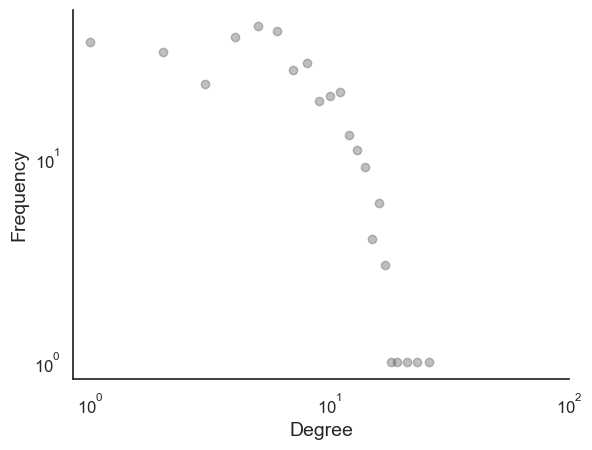

In [146]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import figure
from matplotlib.ticker import MaxNLocator

#Let's plot the Degree distribution of the EEN
fig1, ax1 = plt.subplots()
plt.scatter(degreesDDN, degreeDistributionDDNcount, c='#5F5F5F', alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
ax1.set_xticks([1,10, 100])

plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
plt.savefig('Figures/EpidemiologicalcNetwork_DegreeDistribution.pdf',format='pdf',dpi=300, bbox_inches = "tight") 

plt.show()
plt.close()

In [265]:

genetic_edges = []
tot_edges = []

for e in G_gene_icd_disp_significant_post.edges():
    if e[0] in G_elma_icd_male.nodes() and e[1] in G_elma_icd_male.nodes():
        genetic_edges.append(e)
        tot_edges.append(e)
        
for e in G_elma_icd_male.edges():
    if e not in tot_edges:
        tot_edges.append(e)

In [125]:
male_shared_gen_epi_edges = []

for e in genetic_edges:
    if (e[0],e[1]) in G_elma_icd_male.edges() or (e[1],e[0]) in G_elma_icd_male.edges():
        male_shared_gen_epi_edges.append(e)

for e in G_elma_icd_male.edges():
    if (e[0],e[1]) in genetic_edges or (e[1],e[0]) in genetic_edges:
        if e not in male_shared_gen_epi_edges:
            male_shared_gen_epi_edges.append(e)
len(male_shared_gen_epi_edges)

207

In [268]:
str(stats.hypergeom.sf(len(male_shared_gen_epi_edges)-1, len(tot_edges), len(genetic_edges), G_elma_icd_male.number_of_edges()))

'1.0'

In [156]:
shared_gen_epi_edges

[('D70', 'C38'),
 ('K26', 'K25'),
 ('K26', 'K29'),
 ('K26', 'K22'),
 ('I20', 'I25'),
 ('I20', 'I21'),
 ('I20', 'K04'),
 ('J45', 'J46'),
 ('K52', 'K44'),
 ('N39', 'N41'),
 ('J18', 'J15'),
 ('K22', 'K25'),
 ('K74', 'K31'),
 ('K25', 'K29'),
 ('K29', 'A49'),
 ('G47', 'F51'),
 ('I64', 'I63'),
 ('M81', 'M85'),
 ('C44', 'L82'),
 ('C44', 'L57'),
 ('G45', 'E78'),
 ('F12', 'F20'),
 ('F12', 'F31'),
 ('F12', 'F10'),
 ('F12', 'F23'),
 ('D41', 'C65'),
 ('E12', 'E11'),
 ('M17', 'M24'),
 ('I61', 'G41'),
 ('I61', 'I60'),
 ('A49', 'K50'),
 ('I71', 'I72'),
 ('I72', 'E78'),
 ('K63', 'D12'),
 ('K63', 'K50'),
 ('M19', 'M24'),
 ('C71', 'C34'),
 ('C71', 'D43'),
 ('C25', 'C24'),
 ('C25', 'C22'),
 ('K51', 'D73'),
 ('N19', 'N18'),
 ('L21', 'L82'),
 ('B02', 'N10'),
 ('K55', 'A04'),
 ('M24', 'M67'),
 ('J41', 'J40'),
 ('C67', 'C66'),
 ('C67', 'C68'),
 ('C92', 'D46'),
 ('K83', 'C24'),
 ('K83', 'C22'),
 ('K83', 'K80'),
 ('M94', 'M67'),
 ('M94', 'M22'),
 ('M22', 'M67'),
 ('C22', 'C24'),
 ('E14', 'E10'),
 ('F20', 'F31'

In [269]:
trj_with_genetic_basis = []
trj_with_genetic_basis_dict = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    pairwise_dislist = it.permutations(dislist,2)   #I want to include bot orders
    intersection_dislist = set(male_shared_gen_epi_edges) & set(pairwise_dislist)
    trj_with_genetic_basis_dict[trj] = len(intersection_dislist)
    if len(intersection_dislist)>0:
        trj_with_genetic_basis.append(trj)
trj_with_genetic_basis_dict = dict(sorted(trj_with_genetic_basis_dict.items(), key=lambda item: item[1],reverse=True))

In [270]:
trj_with_genetic_basis_dict

{'57': 12,
 '405': 12,
 '408': 12,
 '438': 11,
 '78': 10,
 '2': 8,
 '366': 8,
 '414': 8,
 '421': 8,
 '216': 7,
 '279': 7,
 '386': 7,
 '79': 6,
 '98': 6,
 '111_272': 6,
 '112': 6,
 '228': 6,
 '338': 6,
 '363': 6,
 '364': 6,
 '378': 6,
 '62': 5,
 '104': 5,
 '131': 5,
 '139': 5,
 '210': 5,
 '232': 5,
 '251': 5,
 '305': 5,
 '313': 5,
 '376': 5,
 '393': 5,
 '424': 5,
 '436': 5,
 '459': 5,
 '56': 4,
 '140': 4,
 '157_240': 4,
 '182': 4,
 '195': 4,
 '203': 4,
 '217': 4,
 '221': 4,
 '248': 4,
 '270': 4,
 '273': 4,
 '308': 4,
 '370': 4,
 '379': 4,
 '388': 4,
 '402': 4,
 '413': 4,
 '423': 4,
 '448': 4,
 '454': 4,
 '457': 4,
 '156': 3,
 '165': 3,
 '167': 3,
 '175': 3,
 '291': 3,
 '318': 3,
 '320': 3,
 '390': 3,
 '397': 3,
 '406': 3,
 '416': 3,
 '445': 3,
 '1': 2,
 '6': 2,
 '15_73': 2,
 '21': 2,
 '29': 2,
 '36': 2,
 '39': 2,
 '54': 2,
 '59': 2,
 '72': 2,
 '74': 2,
 '77': 2,
 '82_87': 2,
 '92': 2,
 '99': 2,
 '100': 2,
 '103': 2,
 '106': 2,
 '119': 2,
 '123': 2,
 '126': 2,
 '134': 2,
 '151': 2,
 '152

In [161]:
len(trj_with_genetic_basis)

172

In [186]:

pairwise_dislist = it.permutations(male_trajectories_dict_filtered_unique['2'],2)   #I want to include bot orders
intersection_dislist = set(shared_gen_epi_edges) & set(pairwise_dislist)
print(intersection_dislist)

{('B09', 'A08'), ('J10', 'A08'), ('B09', 'F50'), ('A08', 'J10'), ('A08', 'F50'), ('B09', 'J10'), ('A08', 'B09'), ('J10', 'B09')}


In [187]:
len(male_trajectories_dict_filtered_unique['2'])

5

# Females

In [14]:
female_trajectories_df_copy=pd.DataFrame()
female_trajectories_df_copy['Community ID'] = female_trajectories_df['Community ID']

new_members_of_com_list=[]
for i in female_trajectories_df['Members'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
female_trajectories_df_copy['Members']=new_members_of_com_list

female_trajectories_df_copy.head()

,Community ID,Members
0,1,"I88-0-9,K56-0-9,K59-0-9,K60-0-9,K56-10-19"
1,2,"A08-0-9,A38-10-19,B01-10-19,H61-10-19,J38-10-19"
2,3,"A38-0-9,B97-0-9,E45-0-9,G47-0-9,H04-0-9,J10-0-..."
3,4,"A41-0-9,C91-0-9,C91-10-19"
4,5,"B00-0-9,B99-0-9,J05-0-9,J31-0-9,J40-0-9,K52-0-..."


In [15]:

female_trajectories_dict={}
for i,v in female_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in allsources_icd_gene_dict_unified.keys():
            dis_list.append(dis)
    female_trajectories_dict[v['Community ID']]=dis_list

#Now, let's remove all the trajectories that are obvious (same disease)
female_trajectories_dict_filtered={}
for trj,dislist in female_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in allsources_icd_gene_dict_unified.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        female_trajectories_dict_filtered[trj]=new_dislist

print(len(female_trajectories_dict_filtered))


352


In [16]:
#Some of these disease-trajectories contain the same diseases, for this reason, now we will focus only on the
#unique disease-trajectories

In [17]:
female_trajectories_dict_filtered_unique=agglomerate_dict(female_trajectories_dict_filtered)

In [18]:
len(female_trajectories_dict_filtered_unique)

301

In [196]:
len(set([x for xs in list(female_trajectories_dict_filtered_unique.values()) for x in xs]))

484

In [197]:
with open('output/female_trajectories_dict_filtered.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/female_trajectories_dict_filtered_unique.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered_unique, handle, protocol=pk.HIGHEST_PROTOCOL)

In [198]:
female_trajectories_dict_filtered_unique_agglomerated_genes={}

for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    female_trajectories_dict_filtered_unique_agglomerated_genes[agg_trj]=tot_genelsit

In [199]:
with open('output/female_trajectories_dict_filtered_unique_agglomerated_genes.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered_unique_agglomerated_genes, handle, protocol=pk.HIGHEST_PROTOCOL)

In [200]:
female_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in female_trajectories_dict_filtered_unique.items():
    overlap_list=[]
    for dis1 in dislist:
        for dis2 in dislist:
            if dis1!=dis2:
                overlap_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[dis1],allsources_icd_gene_dict_unified[dis2]))
    if len(overlap_list)>0:
        female_trajectories_dict_filtered_unique_avg_overlap[com]=sum(overlap_list)/len(overlap_list)
  

In [201]:
#Let's compare against a null distribution

rd_female_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in female_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(list(allsources_icd_gene_dict_unified.keys()),len(dislist))
    for i in range(10000):
        for rd_dis1 in random_dislist:
            for rd_dis2 in random_dislist:
                if rd_dis1!=rd_dis2:
                    rd_overlap_distribution.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[rd_dis1],allsources_icd_gene_dict_unified[rd_dis2])))
                
    rd_female_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2154243039.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


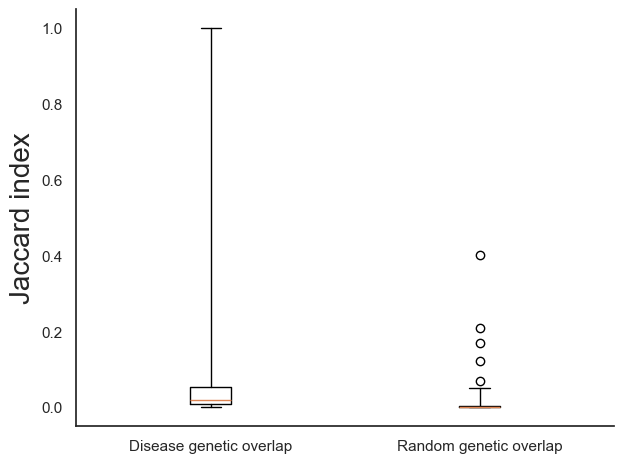

In [202]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_female_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.median(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(female_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()
plt.savefig('Figures/FemaleTrajectories_JI_Random.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [203]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(female_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

1.0126365319568423e-10

In [204]:
tot_filtered_dis_list=[]
for dislist in female_trajectories_dict_filtered_unique.values():
    for dis in dislist:
        if dis not in tot_filtered_dis_list:
            tot_filtered_dis_list.append(dis)
            
print(len(tot_filtered_dis_list))

484


In [213]:
#Let's compare against a null distribution, where we sample only among the 510 diseases present in the disease trajectories

rd_male_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in male_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(tot_filtered_dis_list,len(dislist))
    for i in range(10000):
        for rd_dis1 in random_dislist:
            for rd_dis2 in random_dislist:
                if rd_dis1!=rd_dis2:
                    rd_overlap_distribution.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[rd_dis1],allsources_icd_gene_dict_unified[rd_dis2])))
                
    rd_male_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution
    
    

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_62615/671204940.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


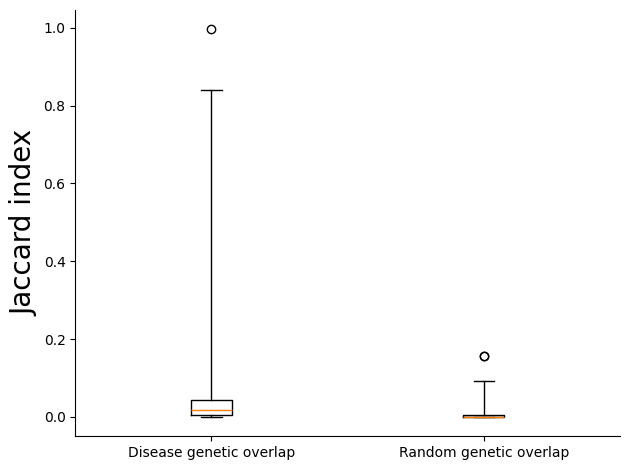

In [214]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_male_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.median(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

In [215]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

2.4371600500658573e-14

In [43]:
#Now, we will look more in the details of this shared relationships, computing the pairs/triplets and so on
#and comparing accordingly each community against its corresponding random distribution
dis_list=list(allsources_icd_gene_dict_unified.keys())
pair_diseases_list=list(it.combinations(dis_list,2))

In [44]:
jaccard_pairs_reference_list=[]

for dispair in pair_diseases_list:
    jaccard_pairs_reference_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
    
print(len(jaccard_pairs_reference_list))

522753


In [48]:
jaccard_pairs_from_n_plets_elma_list_dict={}
jaccard_pairs_from_n_plets_elma_list_pval_dict={}
jaccard_pairs_from_n_plets_elma_list_fdr_dict={}

for s in set([len(v) for v in female_trajectories_dict_filtered_unique.values()]):

    jaccard_pairs_from_n_plets_elma_list=[]
    selected_disnlets=[]
    for trj,dislist in female_trajectories_dict_filtered_unique.items():
        if len(dislist)==s:
            if dislist not in selected_disnlets:
                selected_disnlets.append(dislist)

    selected_dispair_fromnplets=[]
    for disqua in selected_disnlets:
        jo_list=[]
        dispairdisn=list(it.combinations(disqua,2))          
        for dispair in dispairdisn:
            if dispair not in selected_dispair_fromnplets:
                selected_dispair_fromnplets.append(dispair)

    for dispair in selected_dispair_fromnplets:
        try:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
        except:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
            
    jaccard_pairs_from_n_plets_elma_list_dict[s]=jaccard_pairs_from_n_plets_elma_list

    t_value,p_value=stats.ttest_ind(jaccard_pairs_reference_list,jaccard_pairs_from_n_plets_elma_list)
    jaccard_pairs_from_n_plets_elma_list_pval_dict[s] = p_value

adj_pval=fdr_adjustment(list(jaccard_pairs_from_n_plets_elma_list_pval_dict.values()),0.05)
pair_list=list(jaccard_pairs_from_n_plets_elma_list_pval_dict.keys())
for i in range(len(adj_pval)):
    jaccard_pairs_from_n_plets_elma_list_fdr_dict[pair_list[i]]=adj_pval[i]


In [49]:
with open('output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_female.pickle', 'wb') as handle:
    pk.dump(jaccard_pairs_from_n_plets_elma_list_fdr_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [50]:
jaccard_pairs_from_n_plets_elma_list_fdr_dict

{2: 9.185019082712883e-17,
 3: 7.10414547541724e-36,
 4: 6.763728360559969e-16,
 5: 1.4880688919347035e-06,
 6: 1.3816454452724318e-11,
 7: 0.0035285610921244243,
 8: 0.04387313545674903,
 9: 0.7813557092198085,
 10: 0.0021817504107215567,
 11: 0.46592199944596446,
 12: 0.00014504832938685633,
 13: 8.734041453344602e-06,
 14: 0.12878552104143084,
 15: 0.9363290793780488,
 16: 0.21944550306028904,
 20: 0.785827502442357,
 27: 0.715584797481258,
 37: 0.12837598915048434,
 50: 0.26430800894136086,
 62: 0.8434410390045326}

In [209]:
female_trajectories_dict_filtered_unique_DDN_avgsp = {}
for trj,dislist in female_trajectories_dict_filtered_unique.items():
    sp_list = []
    n_dislist = set(dislist) & G_gene_icd_disp_significant_post_lcc.nodes()
    pair_diseases_list=list(it.combinations(n_dislist,2))
    for dispair in pair_diseases_list:
        sp_list.append(nx.shortest_path_length(G_gene_icd_disp_significant_post_lcc, source=dispair[0], target=dispair[1]))
    female_trajectories_dict_filtered_unique_DDN_avgsp[trj] = np.mean(sp_list)
    

/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


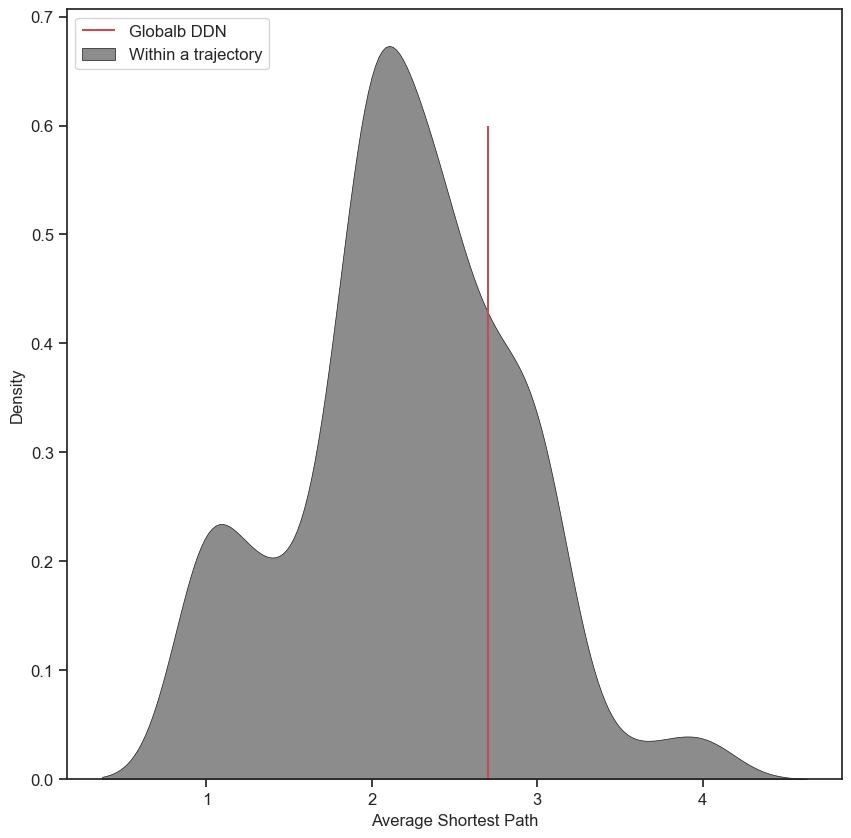

In [210]:
#Let's plot the distribution of all lcc z-scores

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(G_gene_icd_disp_significant_post_avg_sp,ymin=0,ymax=0.6,color='r',label='Globalb DDN')
sns.kdeplot(list(female_trajectories_dict_filtered_unique_DDN_avgsp.values()),color='k',lw=.5,alpha=.5,fill=True,label='Within a trajectory')

plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('Average Shortest Path',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/DDN_ShortestPath_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [211]:

female_trajectories_dict_filtered_unique_DDN_avgsp_sort = {k: v for k, v in sorted(female_trajectories_dict_filtered_unique_DDN_avgsp.items(), key=lambda item: item[1],reverse=False)}




In [ ]:
#Let's calculate the genetic (largest connected component) z-score of the genese perturbed by each trajectory

In [212]:
female_trajectories_dict_filtered_unique_distinct_zscore_dict={}
female_trajectories_dict_filtered_unique_agglomerated_zscore_dict={}

for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
    z_score_list=[]
    for dis in dislist:
        z_score_list.append(allsources_icd_gene_dict_unified_lcczscore[dis])
    female_trajectories_dict_filtered_unique_distinct_zscore_dict[agg_trj]=z_score_list
    
for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    female_trajectories_dict_filtered_unique_agglomerated_zscore_dict[agg_trj]=net_modularity(tot_genelsit,G_ppi)
    

In [213]:
with open('output/female_trajectories_dict_filtered_unique_agglomerated_zscore_dict.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered_unique_agglomerated_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/762931689.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,


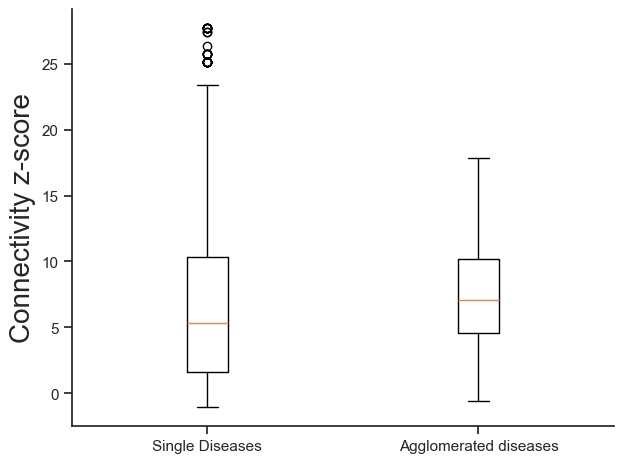

In [214]:
#Let's plot these boxplots

z_score_single_diseases=[]
z_score_agglomerated_diseases=[round(float(z),3) for z in female_trajectories_dict_filtered_unique_agglomerated_zscore_dict.values() if z!='nan']

for trj,z_scorelist in female_trajectories_dict_filtered_unique_distinct_zscore_dict.items():
    for z in z_scorelist:
        if z!='nan':
            z_score_single_diseases.append(round(float(z),3))
            

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Single Diseases','Agglomerated diseases']
plt.ylabel('Connectivity z-score',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[z_score_single_diseases,z_score_agglomerated_diseases]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

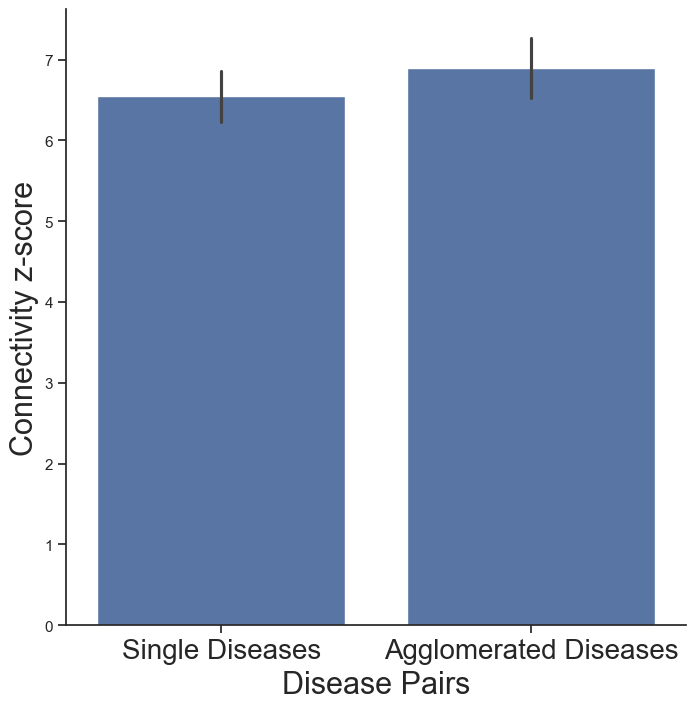

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

connectivity_df=pd.DataFrame()

status_list=[]
conn_list=[]

for i in z_score_single_diseases:
    status_list.append("Single Diseases")
    conn_list.append(i)
    
for i in z_score_agglomerated_diseases:
    status_list.append("Agglomerated Diseases")
    conn_list.append(i)

connectivity_df['Status']=status_list
connectivity_df['Connectivity']=conn_list

# Create a boxplot using seaborn
fig, ax = plt.subplots(figsize=(8, 8))
sns.set(style="white")

g=sns.barplot(x='Status', y='Connectivity', data=connectivity_df)
#g.set_yscale("log")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.xticks(fontsize=20)

plt.xlabel('Disease Pairs', fontsize=22)
plt.ylabel('Connectivity z-score', fontsize=22)
plt.savefig('Figures/Agglomerate_PPI_zscore_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [216]:

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(z_score_single_diseases,z_score_agglomerated_diseases)
p_value

0.3366141352001616

In [60]:
#Let's check for the disease proximity in the PPI

In [61]:
with open('output/icd10_male_trajectories_dict_filtered_unique_proximity_proximity.pickle', 'rb') as handle:
    icd10_male_trajectories_dict_filtered_unique_proximity = pk.load(handle)

In [377]:
def random_selection(G,size):
    while True:
        rnd_sample=rd.sample(list(G.nodes()),size)
        if 'nan' in rnd_sample:
            rnd_sample=rd.sample(list(G.nodes()),size)
        else:
            break
    return rnd_sample


def calculate_closest_distance(G_ppi_lcc, nodes_from, nodes_to):
    values_outer = []
    for node_from in nodes_from:
        values = []
        for node_to in nodes_to:
            if node_from==node_to:
                val =0
            else:
                val=len(nx.shortest_path(G_ppi_lcc,source=node_from, target=node_to))
            values.append(val)
        d = min(values)
        #print d,
        values_outer.append(d)
    d = np.mean(values_outer)
    #print d
    return d

def calculate_proximity(network, nodes_from, nodes_to, exp_random):   #let's calculate the proximity between the two sets
    d=calculate_closest_distance(network,nodes_from,nodes_to)         #exposure and disease genesets
    m=exp_random[len(nodes_from),len(nodes_to)][0]
    s=exp_random[len(nodes_from),len(nodes_to)][1]
    if s == 0:
        z = 0.0
    else:
        z = (d - m) / s
    return d, z, (m, s) #(z, pval)


In [379]:
#Let's complete the proximity calculation

for dispair in missing_dispairs:
    geneset1=icd_genes_ppi_dict[dispair[0]]
    geneset2=icd_genes_ppi_dict[dispair[1]]
    dis_random_distance={}
    S = 1000
    l_rnd_dist = []
    for s in range(S):
        rnd_dis1_set=random_selection(G_ppi,len(geneset1))
        rnd_dis2_set=random_selection(G_ppi,len(geneset2))
        rnd_dist=calculate_closest_distance(G_ppi,rnd_dis1_set,rnd_dis2_set)
        l_rnd_dist.append(rnd_dist)
    mu = np.mean(l_rnd_dist)
    std = np.std(l_rnd_dist)

    dis_random_distance[len(geneset1),len(geneset2)]=[mu,std]
    icd10_male_trajectories_dict_filtered_unique_proximity[dispair[0],dispair[1]]=calculate_proximity(G_ppi,geneset1,geneset2,dis_random_distance)
    


In [62]:


within_pairwise_dist=[]
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    pairwise_dis=it.combinations(dislist,2)
    for dis_pair in pairwise_dis:
        if dis_pair not in within_pairwise_dist:
            within_pairwise_dist.append(dis_pair)
    
    

In [63]:

within_trj_z_score_list=[]
within_trj_net_distance_list=[]
other_trj_z_score_list=[]
other_trj_net_distance_list=[]


for dispair_prox, prox in icd10_male_trajectories_dict_filtered_unique_proximity.items():
    if dispair_prox in within_pairwise_dist:
        within_trj_z_score_list.append(prox[1])
        within_trj_net_distance_list.append(prox[0])
    else:
        other_trj_z_score_list.append(prox[1])
        other_trj_net_distance_list.append(prox[0])

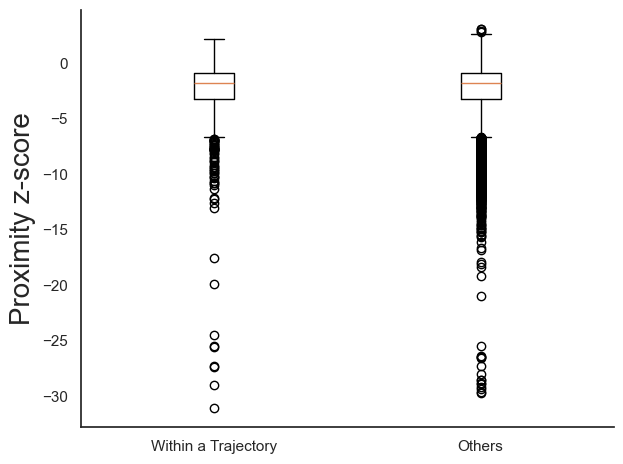

In [64]:
#Let's plot these boxplots


import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Within a Trajectory','Others']
plt.ylabel('Proximity z-score',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[within_trj_z_score_list,other_trj_z_score_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

In [65]:
from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(within_trj_z_score_list,other_trj_z_score_list)
p_value

0.04903006175488214

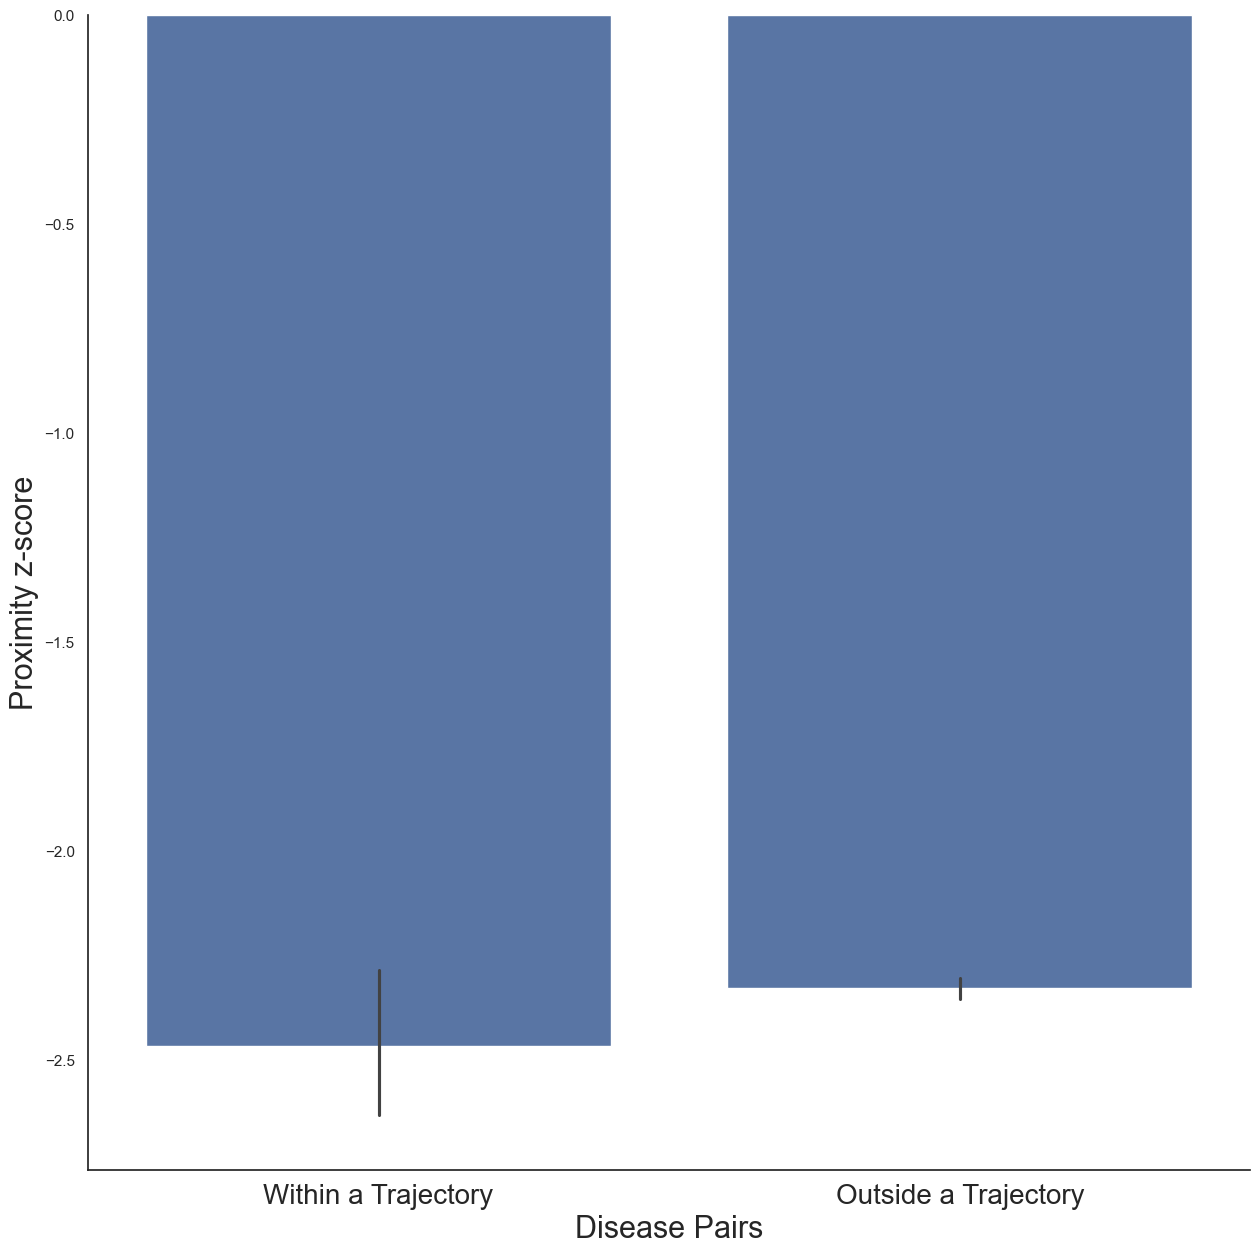

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

proximity_df=pd.DataFrame()

status_list=[]
prox_list=[]

for i in within_trj_z_score_list:
    status_list.append("Within a Trajectory")
    prox_list.append(i)
    
for i in other_trj_z_score_list:
    status_list.append("Outside a Trajectory")
    prox_list.append(i)

proximity_df['Status']=status_list
proximity_df['Proximity']=prox_list

# Create a boxplot using seaborn
fig, ax = plt.subplots(figsize=(15, 15))
sns.set(style="white")

g=sns.barplot(x='Status', y='Proximity', data=proximity_df)
#g.set_yscale("log")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.xticks(fontsize=20)

plt.xlabel('Disease Pairs', fontsize=22)
plt.ylabel('Proximity z-score', fontsize=22)

plt.show()

Text(0, 0.5, 'Number of disease-pairs')

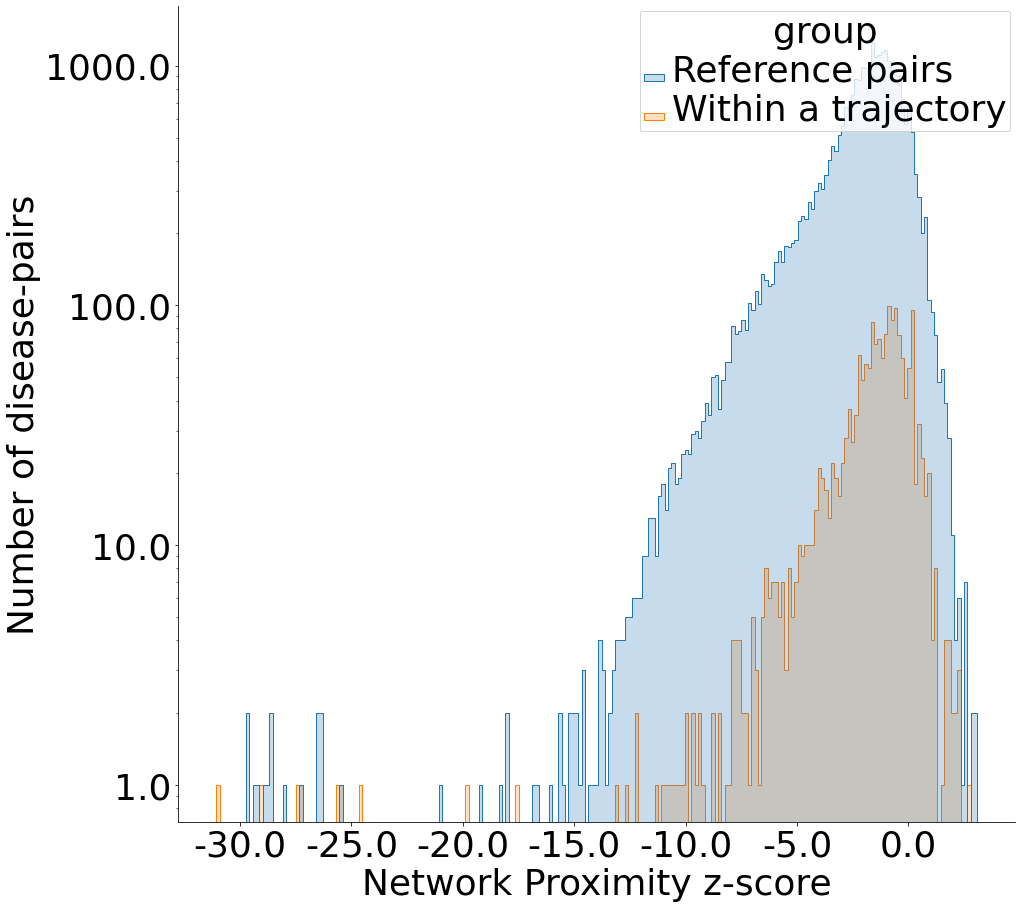

In [383]:
import seaborn as sns

genedispairs_df=pd.DataFrame()

net_proximity_list=[]
group=[]
for ov in other_trj_z_score_list:
    net_proximity_list.append(float(ov))
    group.append("Reference pairs")
        
for ov in within_trj_z_score_list:
    net_proximity_list.append(float(ov))
    group.append("Within a trajectory")
    


genedispairs_df['ov']=net_proximity_list
genedispairs_df['group']=group
fig, ax = plt.subplots(figsize=(15,15))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.yscale('log')
sns.histplot(
    genedispairs_df, x="ov", hue="group", element="step",palette='tab10',
)
ax.set_xticklabels([round(float(i),2) for i in list(ax.get_xticks())], size = 36)
ax.set_yticklabels(ax.get_yticks(), size = 36)
plt.setp(ax.get_legend().get_texts(), fontsize='36') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='36') # for legend title
plt.xlabel('Network Proximity z-score',fontsize=36)
plt.ylabel('Number of disease-pairs', fontsize=36)

/Users/lsd/opt/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1376: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


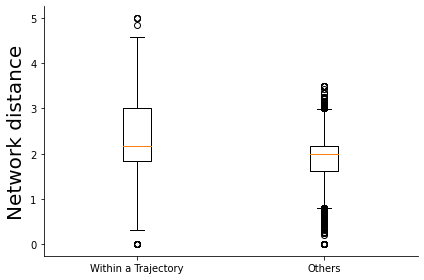

In [384]:
#Let's plot these boxplots


import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Within a Trajectory','Others']
plt.ylabel('Network distance',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[within_trj_net_distance_list,other_trj_net_distance_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

Text(0, 0.5, 'Number of disease-pairs')

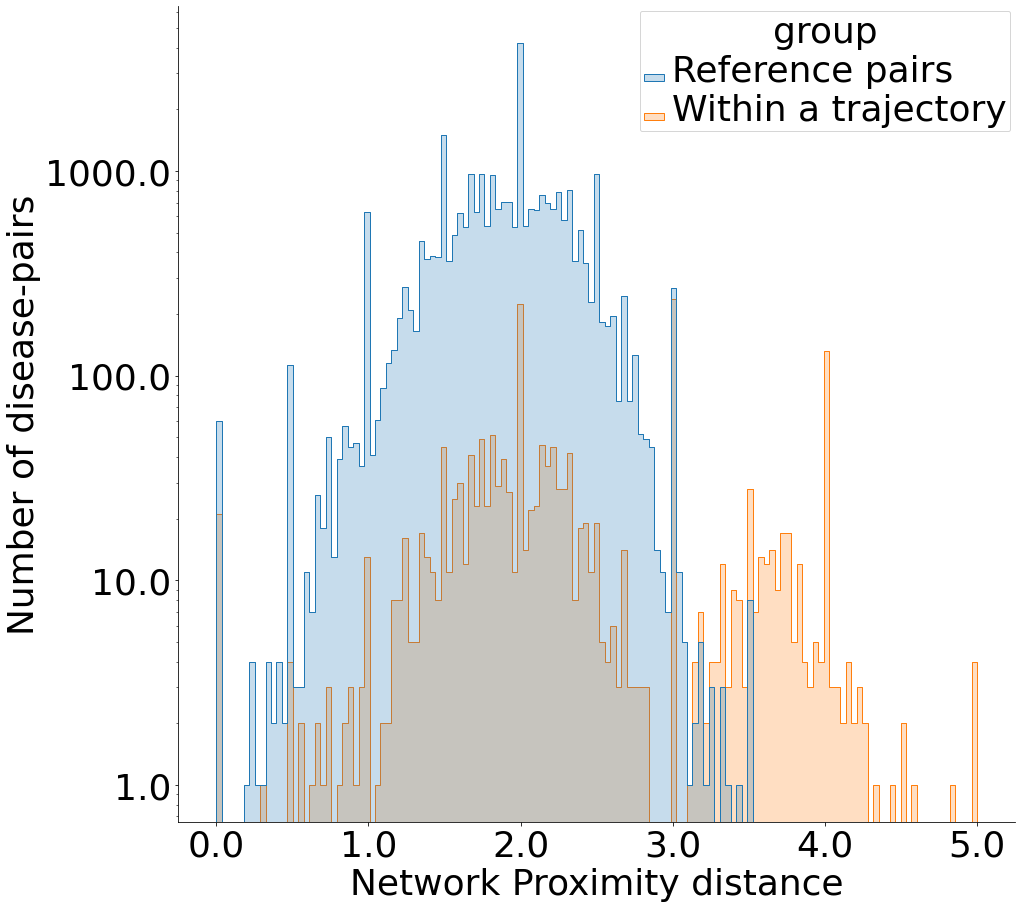

In [385]:
import seaborn as sns

genedispairs_df=pd.DataFrame()

net_proximity_list=[]
group=[]
for ov in other_trj_net_distance_list:
    net_proximity_list.append(float(ov))
    group.append("Reference pairs")
        
for ov in within_trj_net_distance_list:
    net_proximity_list.append(float(ov))
    group.append("Within a trajectory")
    


genedispairs_df['ov']=net_proximity_list
genedispairs_df['group']=group
fig, ax = plt.subplots(figsize=(15,15))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.yscale('log')
sns.histplot(
    genedispairs_df, x="ov", hue="group", element="step",palette='tab10',
)
ax.set_xticklabels([round(float(i),2) for i in list(ax.get_xticks())], size = 36)
ax.set_yticklabels(ax.get_yticks(), size = 36)
plt.setp(ax.get_legend().get_texts(), fontsize='36') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='36') # for legend title
plt.xlabel('Network Proximity distance',fontsize=36)
plt.ylabel('Number of disease-pairs', fontsize=36)

In [388]:
len([i for i in within_trj_z_score_list if i<-2])/len(within_trj_z_score_list)

0.3187118267629095

In [389]:
male_trajectories_dict_filtered_unique_prox_zscore_dict={}
missing_dispairs=[]
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    prox_list=[]
    pairwise_dis=list(it.combinations(dislist,2))
    for dis_pair in pairwise_dis:
        try:
            try:
                prox_list.append(icd10_male_trajectories_dict_filtered_unique_proximity[dis_pair[0],dis_pair[1]][1])
            except:
                prox_list.append(icd10_male_trajectories_dict_filtered_unique_proximity[dis_pair[1],dis_pair[0]][1])
        except:
            missing_dispairs.append(dis_pair)
            
    male_trajectories_dict_filtered_unique_prox_zscore_dict[trj]=np.mean(prox_list)


In [391]:
male_trajectories_dict_filtered_unique_prox_zscore_dict

{'1_2_3_4_5_6_99': -1.5653756495090791,
 '9_10_11_12_100_101_154': -2.1351162404971737,
 '13_227': -0.4401481063104593,
 '15_16_73': -3.9819914461804626,
 '18': -0.48145597805835744,
 '22': -0.1447396044590852,
 '23': -4.279920035293529,
 '24_25': -0.5422314964894683,
 '27_28_29': -0.39626925050185463,
 '39_40': 0.002380103440056631,
 '41_42_234': -0.8122143098601243,
 '50': -1.8527173781753579,
 '51_181_282_362_402_403_404': -6.7918171150686035,
 '56': -0.42557150686060435,
 '57': -0.8847709408468601,
 '59': -2.0922775700635072,
 '61': -5.442960981276046,
 '62': -1.04122596404851,
 '63_326_327_455': 0.4406753814309485,
 '64_65': 0.6846856832182645,
 '66': -1.63003530500098,
 '68': -1.1510182795843134,
 '70_114': -2.906424028565798,
 '72': -6.402798066675368,
 '74': -1.6717752492037858,
 '77': -2.5469966483510618,
 '78': -7.444912975513138,
 '79_80_81': -0.9020555050659272,
 '82_87_88': -3.713447879462143,
 '84': -0.4682591699696143,
 '91_191_395_396_397': -1.0110814027100166,
 '92': -

In [19]:
#Let's create a network now out of this condensed unique trajectories
#We are going to focus on those trajectories that have less than 8 elements because we have shown that those are the ones
#that have the highest coherence with the genetic basis
G_elma_icd_female = nx.Graph() 

for dislist in list(female_trajectories_dict_filtered_unique.values()):
    if len(dislist)<9:
        for dis1 in dislist:
            for dis2 in dislist:
                if dis1!=dis2:
                    G_elma_icd_female.add_edge(dis1, dis2)
                
print(G_elma_icd_female.number_of_nodes())
print(G_elma_icd_female.number_of_edges())

381
1189


In [20]:
G_elma_icd_female_df = nx.to_pandas_edgelist(G_elma_icd_female,'Dis A', 'Dis B')
G_elma_icd_female_df.to_csv('output/G_elma_icd_female_df.tsv', sep = '\t')

In [218]:
from cartoGRAPHs import *
import random 
from sklearn.decomposition import PCA
from sklearn import preprocessing
import json
import matplotlib.colors as mcolors
import colorsys
import pickle as pk

In [219]:
icd_cat = set([str(n[0]) for n in G_elma_icd_female.nodes()])

In [220]:
icd_code_comm = {}
for icd in icd_cat:
    nodelist = []
    for node in G_elma_icd_female.nodes():
        if icd in node:
            nodelist.append(node)
    icd_code_comm[icd] = nodelist

In [221]:
# creating a feature dataframe based on community
feature_df = pd.DataFrame()
    
for g in G_elma_icd_female.nodes():
    feature_list=[]
    for icd, nodelist in icd_code_comm.items():
        if g in nodelist:
            feature_list.append(1)
        else:
            feature_list.append(0)
    feature_df[g]=feature_list


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2304266199.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2304266199.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_15633/2304266199.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [222]:
feature_df_T=feature_df.T

In [223]:
r = 0.9
alpha = 1.0

A = nx.adjacency_matrix(G_elma_icd_female, nodelist=list(G_elma_icd_female.nodes()))
DM_m = rnd_walk_matrix2(A, r, alpha, len(G_elma_icd_female.nodes()))
FM_structural = pd.DataFrame(DM_m)
FM_structural.sum(axis=1) # axis=1 for columns i.e. features = sum 1
FM_structural.index=list(G_elma_icd_female.nodes())
FM_structural.columns=list(G_elma_icd_female.nodes())
FM_structural

,I88,K56,K59,K60,A08,A38,B01,H61,B00,B99,...,K72,M00,C23,D31,H04,H16,M10,G31,J81,J47
I88,9.012947e-01,1.318407e-02,7.738677e-03,1.319843e-02,4.014065e-08,1.411872e-09,1.411872e-09,8.036466e-10,7.105736e-08,1.379854e-07,...,2.784406e-12,7.485193e-10,2.625660e-09,5.351636e-08,5.351636e-08,5.351636e-08,5.166437e-11,2.506090e-09,1.852270e-11,5.855146e-10
K56,1.845770e-02,9.012015e-01,7.780494e-03,1.327328e-02,1.879502e-06,6.605943e-08,6.605943e-08,3.622105e-08,4.110840e-06,8.106538e-06,...,9.124031e-11,1.032696e-09,8.191483e-08,5.193938e-08,5.193938e-08,5.193938e-08,9.603992e-10,2.067918e-09,1.473417e-10,2.765784e-08
K59,1.857283e-02,1.333799e-02,9.010170e-01,1.335171e-02,1.520264e-06,5.353934e-08,5.353934e-08,3.237651e-08,1.263487e-06,2.326687e-06,...,8.491734e-11,8.660475e-08,1.696838e-07,6.006341e-06,6.006341e-06,6.006341e-06,4.372730e-09,2.063053e-07,1.933976e-09,2.175249e-08
K60,1.847780e-02,1.327328e-02,7.788496e-03,9.021978e-01,4.041074e-08,1.421232e-09,1.421232e-09,8.049925e-10,7.080552e-08,1.382083e-07,...,2.070806e-12,7.527945e-10,2.641944e-09,5.195921e-08,5.195921e-08,5.195921e-08,5.129295e-11,1.802145e-09,1.862635e-11,5.893813e-10
A08,4.014065e-08,1.342502e-06,6.334435e-07,2.886481e-08,9.019078e-01,3.151664e-02,3.151664e-02,1.207465e-02,1.711650e-06,1.027546e-07,...,2.000280e-07,3.680312e-10,2.432163e-08,2.690210e-11,2.690210e-11,2.690210e-11,2.574313e-09,3.406749e-10,5.047280e-10,3.618957e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H16,6.421964e-08,4.451947e-08,3.003170e-06,4.453646e-08,3.228252e-11,2.067565e-11,2.067565e-11,5.673114e-10,5.536024e-08,1.049017e-07,...,1.804672e-14,8.346851e-12,8.612625e-13,1.602731e-02,1.602731e-02,9.012732e-01,5.367403e-11,7.281995e-11,4.151813e-13,8.387486e-13
M10,1.033287e-11,1.371999e-10,3.643942e-10,7.327564e-12,5.148626e-10,1.819357e-11,1.819357e-11,1.275094e-11,1.407967e-08,2.775401e-08,...,2.412243e-11,8.719801e-12,7.433620e-09,8.945672e-12,8.945672e-12,8.945672e-12,9.010020e-01,1.287307e-13,1.265054e-07,1.103576e-09
G31,1.503654e-09,8.862504e-10,5.157632e-08,7.723479e-10,2.044049e-10,7.277650e-12,7.277650e-12,6.646939e-12,2.706643e-08,7.207191e-10,...,3.611010e-13,1.334171e-11,5.201183e-11,3.640998e-11,3.640998e-11,3.640998e-11,3.861921e-13,9.013713e-01,1.582716e-14,3.222765e-12
J81,1.481816e-11,8.419524e-11,6.446586e-10,1.064363e-11,4.037824e-10,1.430399e-11,1.430399e-11,1.103339e-11,7.729250e-10,1.523860e-09,...,2.500786e-11,6.333066e-13,5.310129e-06,2.767875e-13,2.767875e-13,2.767875e-13,5.060217e-07,2.110289e-14,9.010544e-01,4.085797e-08


In [224]:
scalar_val = 0.55
layout_method = 'modulated-scal'+str(scalar_val)
DF_structural = FM_structural
DF_functional = feature_df
DF_merge = feature_modulation(DF_structural,DF_functional, scalar_val)

n_n = 10
spr = 2
md = 1.5
metr2D = 'cosine'

posG2D_modulated = layout_portrait_umap(G_elma_icd_female,
                                   DF_merge,
                                   2,
                                   n_neighbors=n_n, 
                                   spread=spr, 
                                   min_dist=md, 
                                   metric=metr2D
                                  )

posG2D_new = posG2D_modulated

/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [225]:
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1

edge_opacity = 0.5
edge_width = 0.1
edge_color = '#A1A1A1' #'#6C6C6C' #'#d3d3d3'

In [226]:
with open('output/icd_cat_color_mapping.pickle', 'rb') as handle:
    icd_cat_color_mapping = pk.load(handle)

In [227]:
def draw_node_degree(G, scalef):
    '''
    Calculate the node degree from graph positions (dict).
    Return list of radii for each node (2D). 
    '''
    
    l_size = {}
    for node in G.nodes():
        k = nx.degree(G, node)
        if k > 0:
            R = k*scalef +0.25 #math.log(k) * scalef + 0.25
        else: 
            R = 0.1
        l_size[node] = R
        
    return l_size

scale_factor = 15 #0.15
d_size = draw_node_degree(G_elma_icd_female, scale_factor)
l_size = [d_size[n] for n in posG2D_new.keys()]

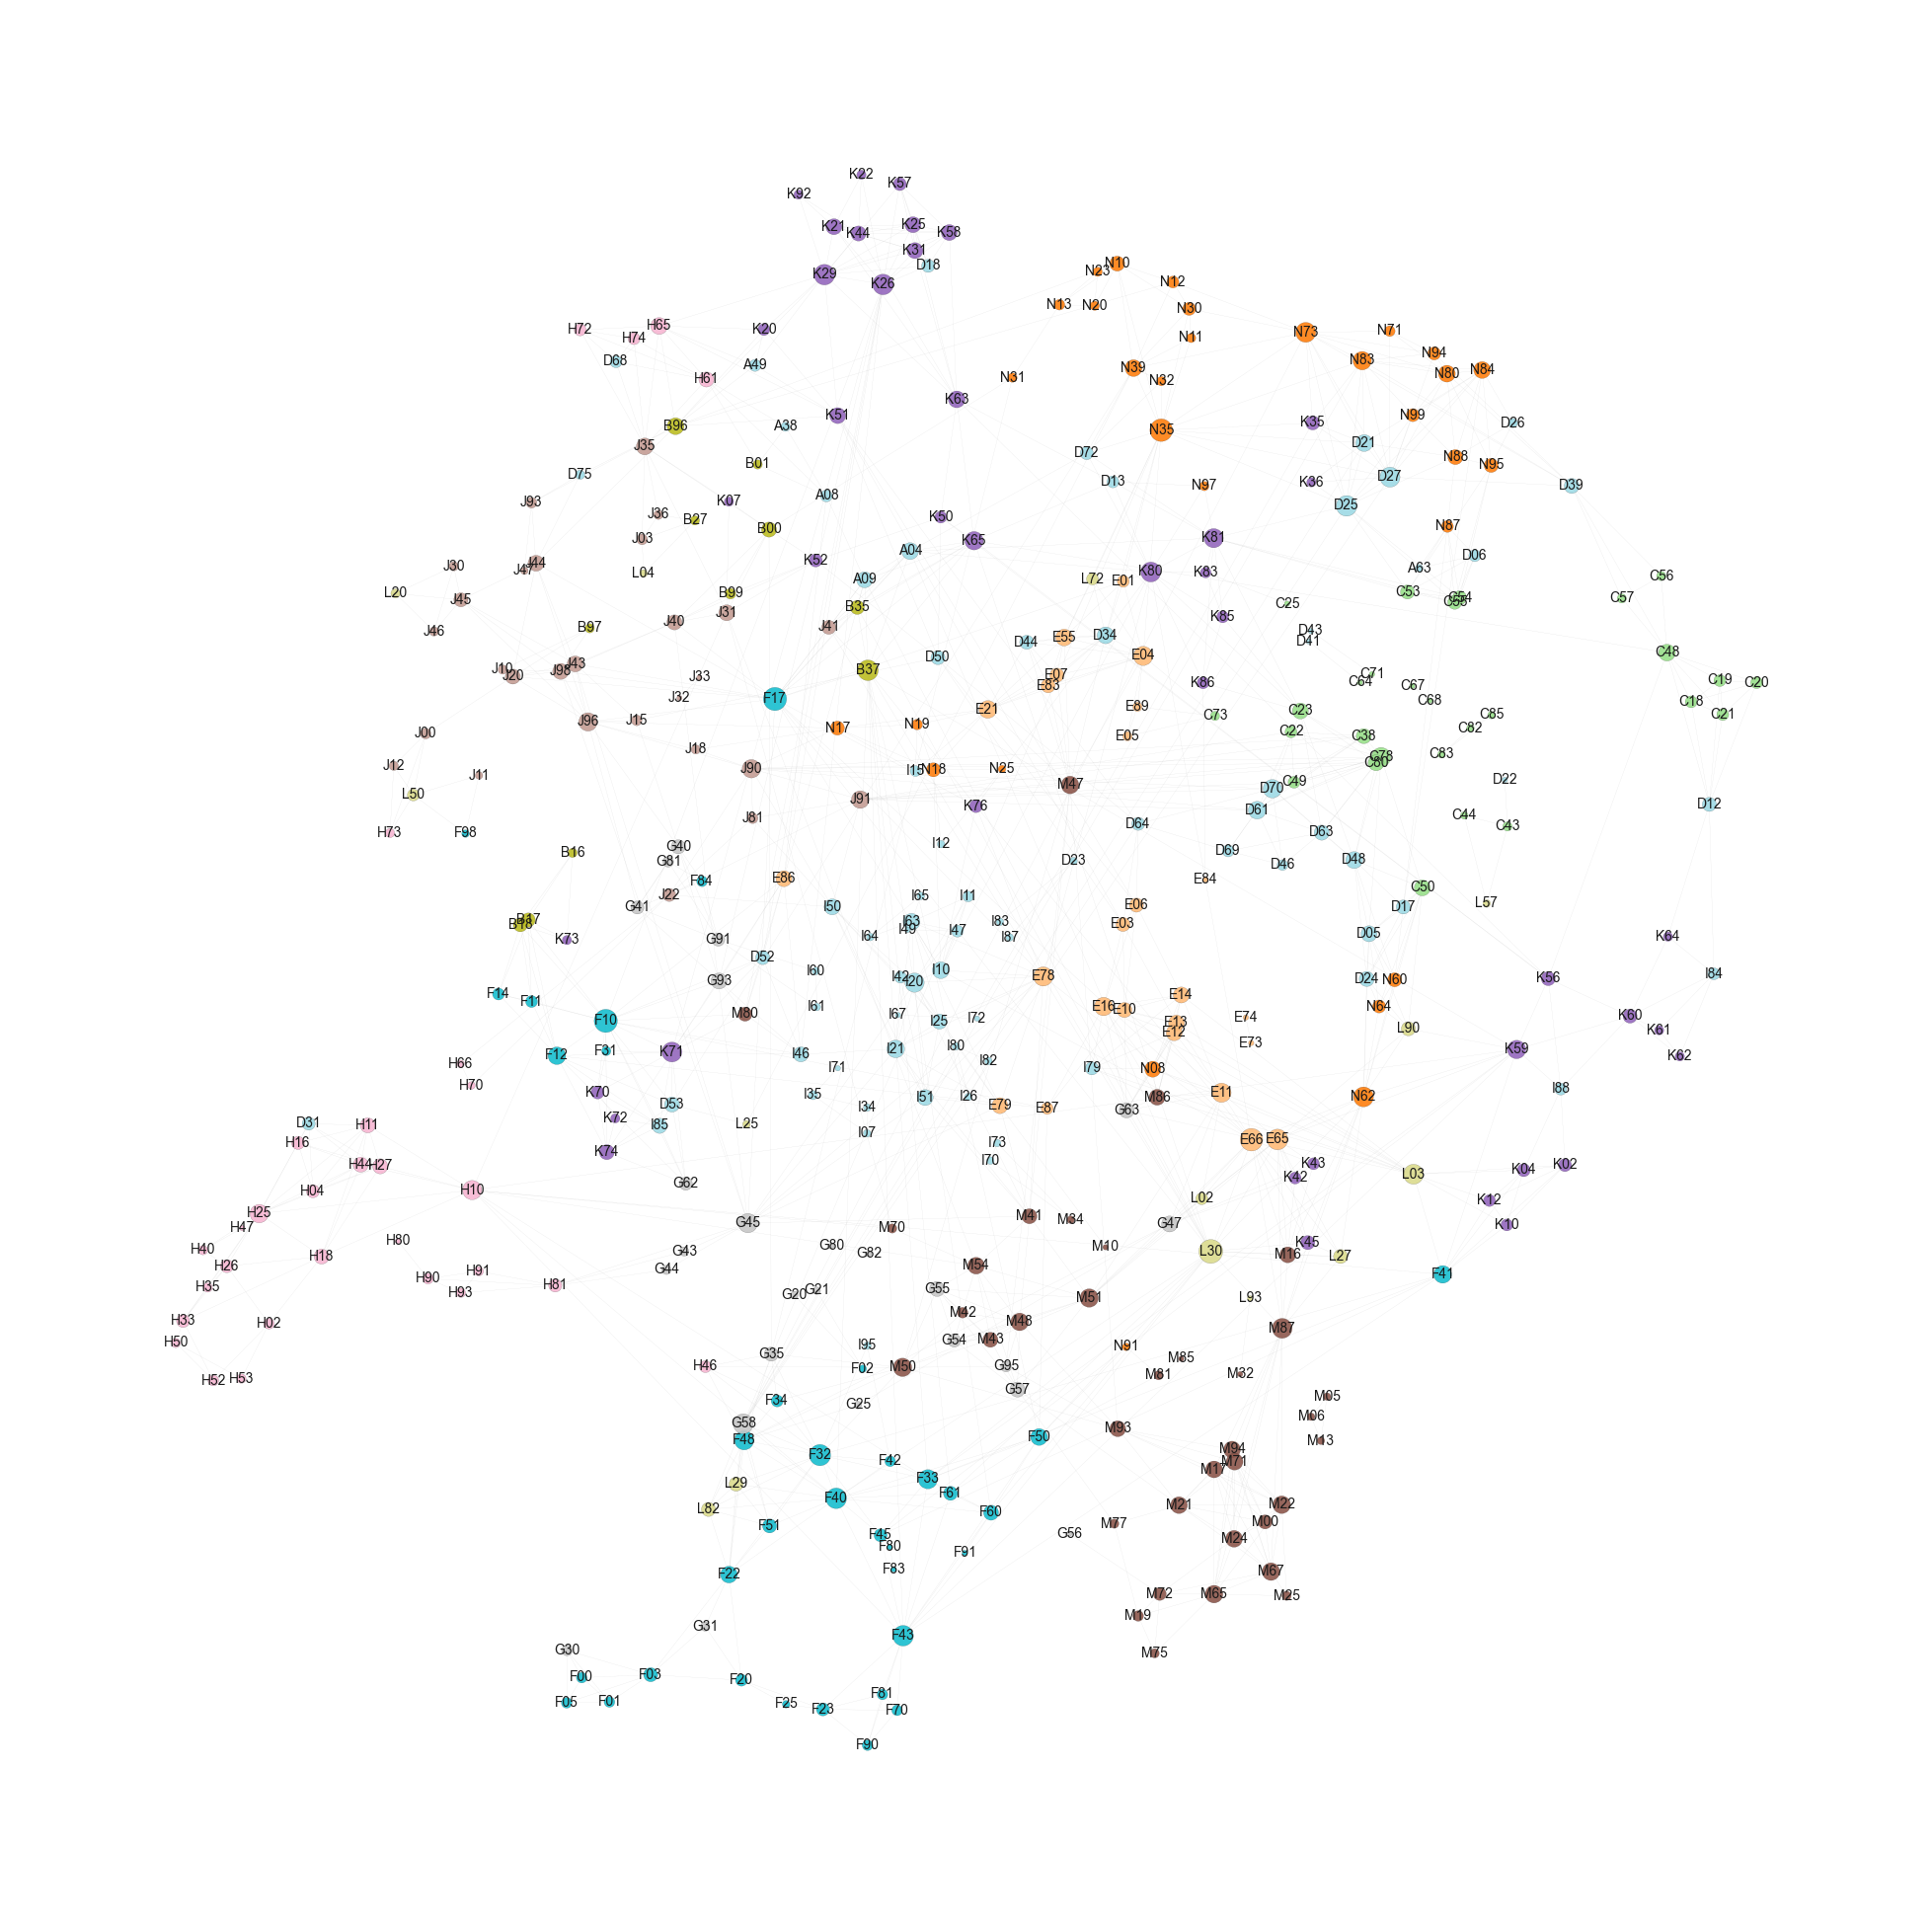

In [228]:
color_list = []
for node in posG2D_new.keys():
    color_list.append(icd_cat_color_mapping[node[0]])


plt.figure(figsize=(25,25))
nx.draw_networkx_nodes(G_elma_icd_female, 
                       posG2D_new,
                       edgecolors = node_edge_col, 
                       linewidths = node_linewidth, 
                       node_color = color_list, 
                       node_size = l_size, 
                       alpha = opacity_nodes)

nx.draw_networkx_edges(G_elma_icd_female, posG2D_new,  width = edge_width, edge_color = edge_color, alpha = edge_opacity)
plt.box(False)
nx.draw_networkx_labels(G_elma_icd_female,pos=posG2D_new,font_size=10)
plt.savefig('Figures/Supp_EpiNet_DDN_Female.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()



In [235]:
G_elma_icd_female_degree=dict(nx.degree(G_elma_icd_female))
dict(sorted(G_elma_icd_female_degree.items(), key=lambda item: item[1],reverse=True))

{'L30': 20,
 'F17': 19,
 'F10': 19,
 'N35': 18,
 'E66': 18,
 'F32': 16,
 'F43': 15,
 'K29': 15,
 'D25': 15,
 'E65': 15,
 'B37': 15,
 'K26': 15,
 'F40': 15,
 'L03': 14,
 'D27': 14,
 'N73': 14,
 'K80': 14,
 'K71': 14,
 'N62': 14,
 'G58': 14,
 'M87': 14,
 'E78': 13,
 'F33': 13,
 'E04': 13,
 'E11': 13,
 'F48': 13,
 'K81': 13,
 'C78': 13,
 'G45': 13,
 'I20': 13,
 'H10': 13,
 'K59': 12,
 'D70': 12,
 'E16': 12,
 'N83': 12,
 'J96': 12,
 'M51': 12,
 'M50': 12,
 'J90': 12,
 'K65': 12,
 'H25': 12,
 'F41': 11,
 'F12': 11,
 'M22': 11,
 'M65': 11,
 'M67': 11,
 'M48': 11,
 'I21': 11,
 'E21': 11,
 'D61': 11,
 'J91': 11,
 'M47': 11,
 'B96': 10,
 'H65': 10,
 'J35': 10,
 'N39': 10,
 'I10': 10,
 'M54': 10,
 'D48': 10,
 'N84': 10,
 'N80': 10,
 'F50': 10,
 'K63': 10,
 'M24': 10,
 'M94': 10,
 'D21': 10,
 'I63': 10,
 'M17': 10,
 'C48': 10,
 'D34': 10,
 'E55': 10,
 'M21': 10,
 'M71': 10,
 'A04': 10,
 'F22': 10,
 'J31': 9,
 'J98': 9,
 'E14': 9,
 'K21': 9,
 'E86': 9,
 'A09': 9,
 'G47': 9,
 'K25': 9,
 'K31': 9,
 

In [245]:
for e in G_elma_icd_female.edges():
    if 'L30' in e:
        print(e)

('E66', 'L30')
('F17', 'L30')
('F43', 'L30')
('F33', 'L30')
('F60', 'L30')
('A09', 'L30')
('E65', 'L30')
('F50', 'L30')
('B37', 'L30')
('F40', 'L30')
('K65', 'L30')
('N62', 'L30')
('M16', 'L30')
('F61', 'L30')
('M87', 'L30')
('A04', 'L30')
('B35', 'L30')
('L30', 'K45')
('L30', 'L27')
('L30', 'J41')


In [230]:
for e in G_elma_icd_female.edges():
    if 'F17' in e:
        print(e)

('J40', 'F17')
('J20', 'F17')
('J98', 'F17')
('E66', 'F17')
('E78', 'F17')
('F17', 'I10')
('F17', 'K76')
('F17', 'K80')
('F17', 'J44')
('F17', 'J43')
('F17', 'J96')
('F17', 'G45')
('F17', 'A04')
('F17', 'A09')
('F17', 'B35')
('F17', 'B37')
('F17', 'J41')
('F17', 'K65')
('F17', 'L30')


In [244]:
mf_intersection = set(dict(G_elma_icd_female['F17']).keys()) & set(dict(G_elma_icd_male['F17']).keys())
for dis in set(dict(G_elma_icd_male['F17']).keys()):
    if dis not in mf_intersection:
        print(dis)


J15
F12
F10
J93
K04
D51
B94
H49
K12
E87
J42
F20
J02
G58
F23
F60


In [246]:
#Extract degrees from the DDN
degrees_DDN = [x[1] for x in  nx.degree(G_elma_icd_female)]
#Get the unique PPI degree steps

degrees_DDN_unique = list(set(degrees_DDN))
degrees_DDN_unique.sort()

#degree for x axis (sorted from small to biggest)
degreesDDN = []

#Normal distribution (i.e. P(k = x))
degreeDistributionDDN = []
degreeDistributionDDNcount = []

for degree in degrees_DDN_unique:
    degreesDDN.append(degree)
    degreeDistributionDDN.append(degrees_DDN.count(degree)/float(len(degrees_DDN)))
    degreeDistributionDDNcount.append(degrees_DDN.count(degree))

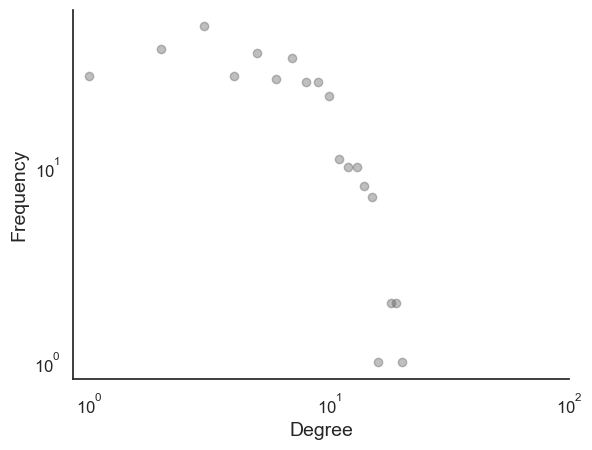

In [247]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import figure
from matplotlib.ticker import MaxNLocator

#Let's plot the Degree distribution of the EEN
fig1, ax1 = plt.subplots()
plt.scatter(degreesDDN, degreeDistributionDDNcount, c='#5F5F5F', alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
ax1.set_xticks([1,10, 100])

plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
plt.savefig('Figures/EpidemiologicalcNetwork_DegreeDistributionFemale.pdf',format='pdf',dpi=300, bbox_inches = "tight") 

plt.show()
plt.close()

In [82]:

genetic_edges = []
tot_edges = []

for e in G_gene_icd_disp_significant_post.edges():
    if e[0] in G_elma_icd_female.nodes() and e[1] in G_elma_icd_female.nodes():
        genetic_edges.append(e)
        tot_edges.append(e)
        
for e in G_elma_icd_female.edges():
    if e not in tot_edges:
        tot_edges.append(e)

In [83]:
female_shared_gen_epi_edges = []

for e in genetic_edges:
    if (e[0],e[1]) in G_elma_icd_female.edges() or (e[1],e[0]) in G_elma_icd_female.edges():
        female_shared_gen_epi_edges.append(e)

for e in G_elma_icd_female.edges():
    if (e[0],e[1]) in genetic_edges or (e[1],e[0]) in genetic_edges:
        if e not in female_shared_gen_epi_edges:
            female_shared_gen_epi_edges.append(e)
len(female_shared_gen_epi_edges)

303

In [84]:
str(stats.hypergeom.sf(len(female_shared_gen_epi_edges)-1, len(tot_edges), len(genetic_edges), G_elma_icd_female.number_of_edges()))

'1.0'

In [122]:
female_trj_with_genetic_basis = []
female_trj_with_genetic_basis_dict = {}
for trj,dislist in female_trajectories_dict_filtered_unique.items():
    pairwise_dislist = list(it.combinations(dislist,2))
    trj_gen_epi_distlist = []
    for dispair in pairwise_dislist:
        if (dispair[0],dispair[1]) in female_shared_gen_epi_edges or (dispair[1],dispair[0]) in female_shared_gen_epi_edges:
            trj_gen_epi_distlist.append(dispair)
    female_trj_with_genetic_basis_dict[trj] = len(trj_gen_epi_distlist)/len(pairwise_dislist)
    if len(trj_gen_epi_distlist)>0:
        female_trj_with_genetic_basis.append(trj)
female_trj_with_genetic_basis_dict = dict(sorted(female_trj_with_genetic_basis_dict.items(), key=lambda item: item[1],reverse=True))

In [143]:
female_trajectories_dict_filtered_unique['187']

['F20', 'F25']

In [130]:
male_trj_with_genetic_basis = []
male_trj_with_genetic_basis_dict = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    pairwise_dislist = list(it.combinations(dislist,2))
    trj_gen_epi_distlist = []
    for dispair in pairwise_dislist:
        if (dispair[0],dispair[1]) in male_shared_gen_epi_edges or (dispair[1],dispair[0]) in male_shared_gen_epi_edges:
            trj_gen_epi_distlist.append(dispair)
    male_trj_with_genetic_basis_dict[trj] = len(trj_gen_epi_distlist)/len(pairwise_dislist)
    if len(trj_gen_epi_distlist)>0:
        male_trj_with_genetic_basis.append(trj)
male_trj_with_genetic_basis_dict = dict(sorted(male_trj_with_genetic_basis_dict.items(), key=lambda item: item[1],reverse=True))

In [274]:
ml_shared_gen_epi_edges = [] 
for dispair in female_shared_gen_epi_edges:
    if (dispair[0],dispair[1]) in male_shared_gen_epi_edges or (dispair[1],dispair[0]) in male_shared_gen_epi_edges:
        ml_shared_gen_epi_edges.append(dispair)

for dispair in male_shared_gen_epi_edges:
    if (dispair[0],dispair[1]) in female_shared_gen_epi_edges or (dispair[1],dispair[0]) in female_shared_gen_epi_edges:
        if dispair not in ml_shared_gen_epi_edges:
            ml_shared_gen_epi_edges.append(dispair)

print(len(ml_shared_gen_epi_edges))

130
